## Imports

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("../data/cleaned.csv")

In [37]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date',
       'Time_Orderd', 'Time_Order_picked', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'Time_taken(min)',
       'delivery_city'],
      dtype='object')

## Seperate colunms

In [38]:
cat = ['Delivery_person_Age','Weatherconditions','Road_traffic_density', 'Vehicle_condition', 'Type_of_order','Type_of_vehicle','Festival','delivery_city']
num = ['Delivery_person_Ratings','multiple_deliveries']
mix = ['Order_Date','Time_Orderd', 'Time_Order_picked']
tgt = 'Time_taken(min)'

## Univariate

### Numerical

In [39]:
from utils import *

UNIVARIATE ANALYSIS FOR NUMERICAL COLUMNS

ANALYZING: Delivery_person_Ratings

1. DESCRIPTIVE STATISTICS:
count    38064.00000
mean         4.63187
std          0.31695
min          2.50000
25%          4.50000
50%          4.70000
75%          4.90000
max          5.00000
Name: Delivery_person_Ratings, dtype: float64

2. SKEWNESS: -1.772
   → Highly left-skewed (negative skew)

3. OUTLIER DETECTION (IQR method):
   - Lower bound: 3.90
   - Upper bound: 5.50
   - Number of outliers: 1030 (2.71%)
   - Outlier values: [2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5]


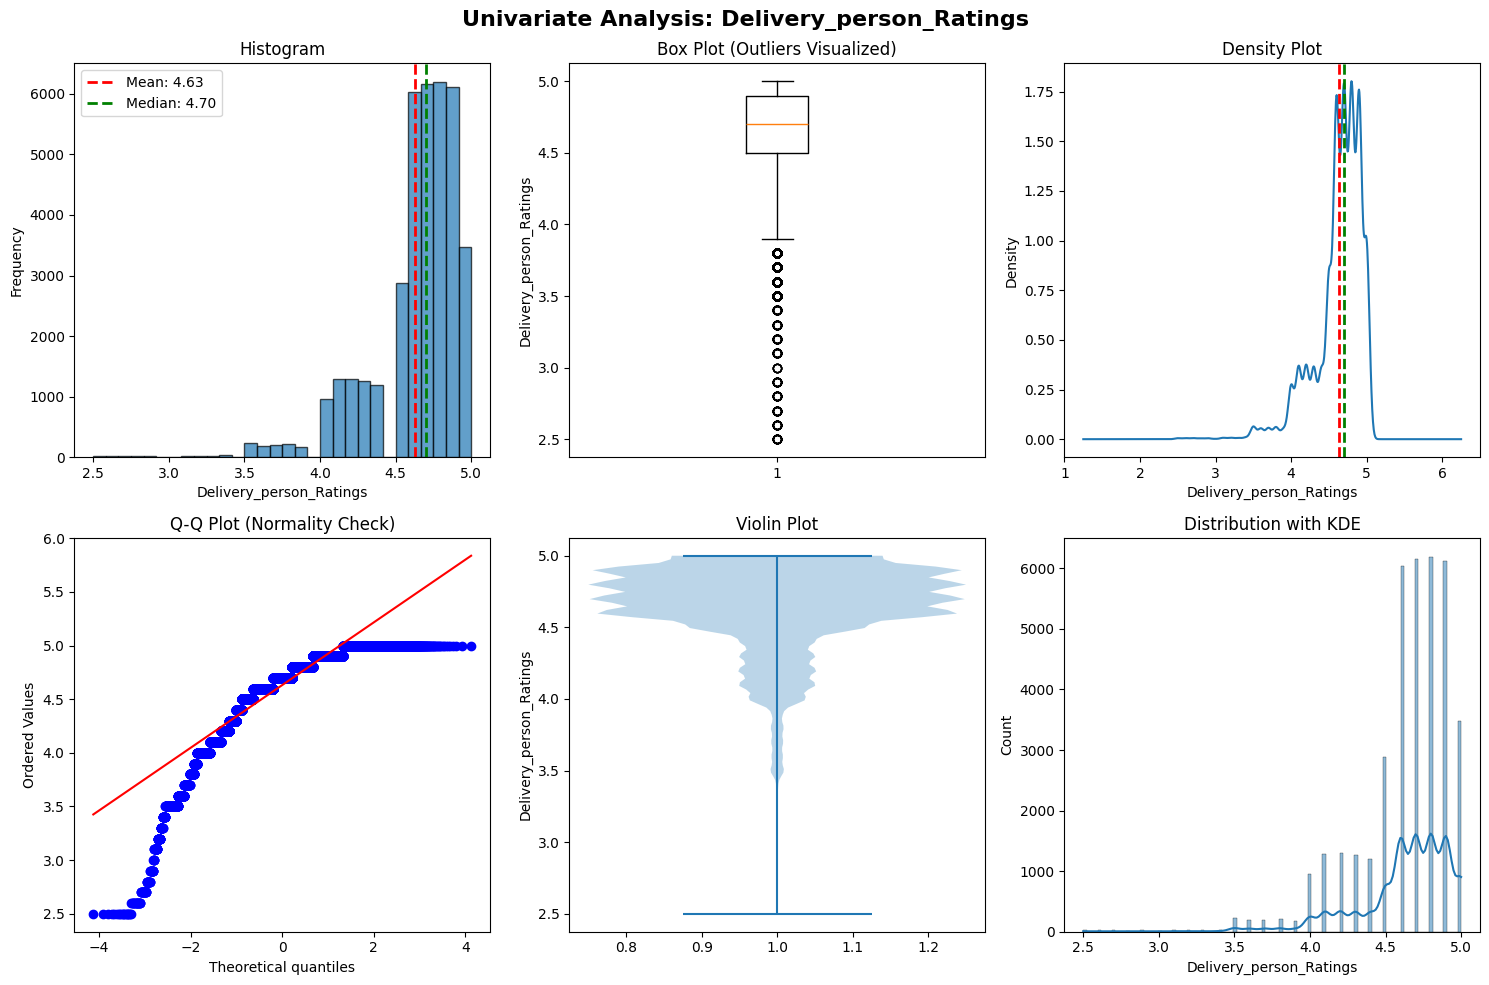


4. RECOMMENDATIONS:
   → High skewness detected (-1.77). Consider:
      - Log transformation: np.log1p(df[col])
      - Square root transformation: np.sqrt(df[col])
      - Box-Cox transformation: scipy.stats.boxcox(df[col])
   → 2.7% outliers present. Consider:
      - Keeping if they represent real extreme values
      - Removing if they are data entry errors
      - Using robust metrics (median, IQR)

--------------------------------------------------

ANALYZING: multiple_deliveries

1. DESCRIPTIVE STATISTICS:
count    38064.000000
mean         0.748818
std          0.572731
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: multiple_deliveries, dtype: float64

2. SKEWNESS: 0.320
   → Approximately symmetric

3. OUTLIER DETECTION (IQR method):
   - Lower bound: -1.50
   - Upper bound: 2.50
   - Number of outliers: 306 (0.80%)
   - Outlier values: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


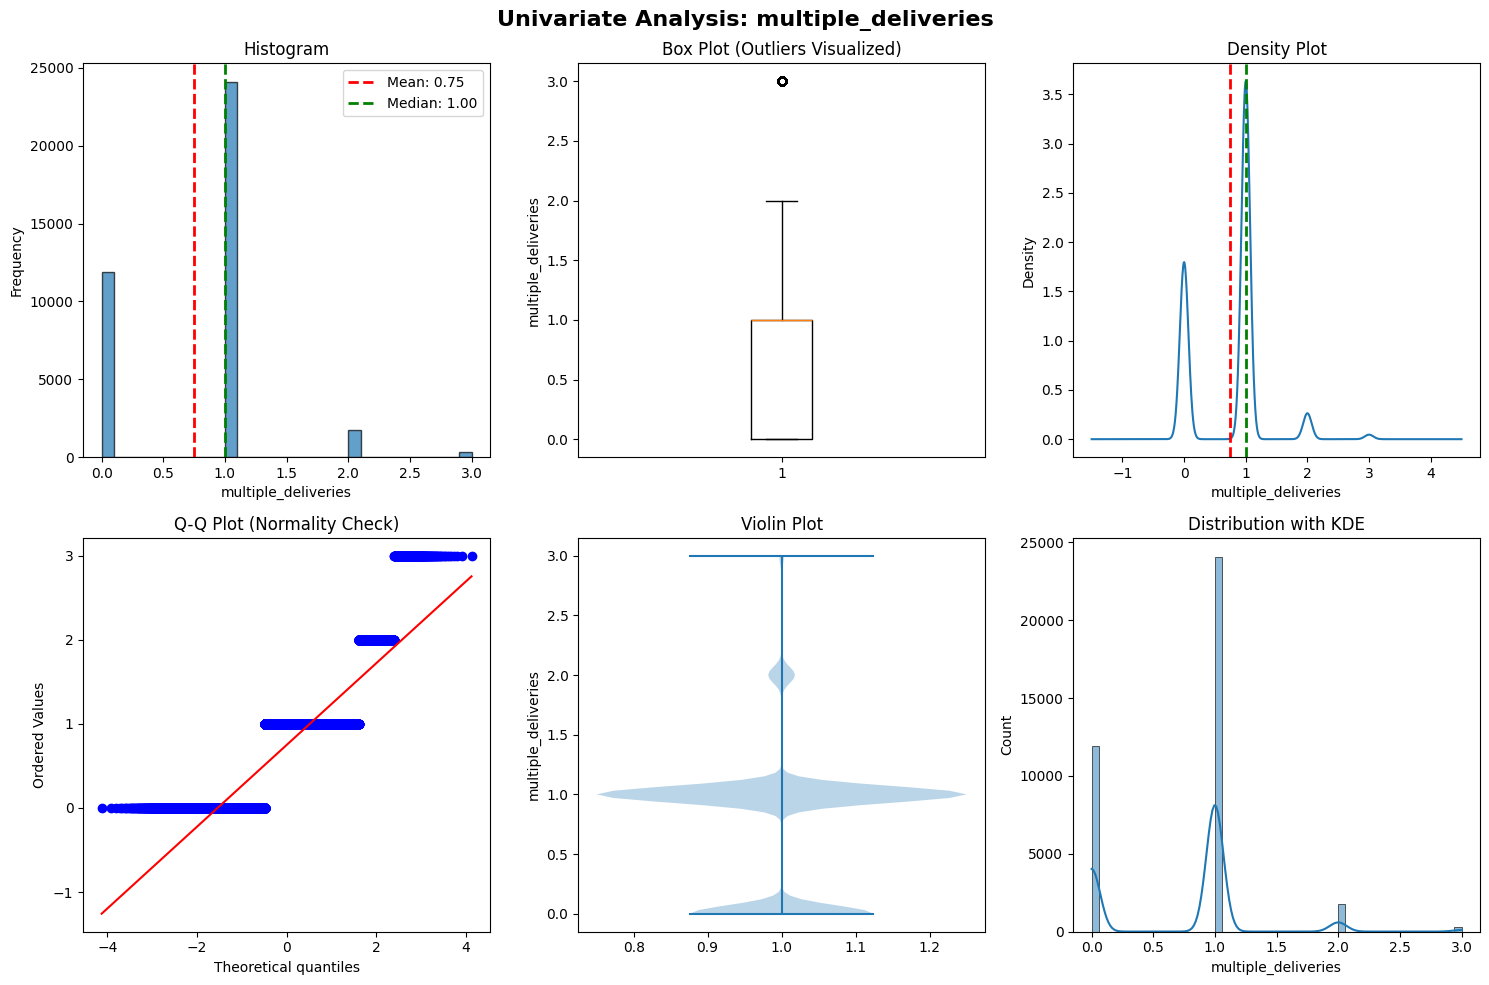


4. RECOMMENDATIONS:
   → Skewness is within acceptable range. No transformation needed.
   → 0.8% outliers present. Consider:
      - Keeping if they represent real extreme values
      - Removing if they are data entry errors
      - Using robust metrics (median, IQR)

--------------------------------------------------

OVERALL SUMMARY OF ALL NUMERICAL COLUMNS
                 Column   Count     Mean      Std  Min  25%  50% (Median)  75%  Max  Skewness  Outlier_Count  Outlier_Percentage  Missing_Count  Missing_Percentage
Delivery_person_Ratings 38064.0 4.631870 0.316950  2.5  4.5           4.7  4.9  5.0 -1.771967           1030            2.705969              0                 0.0
    multiple_deliveries 38064.0 0.748818 0.572731  0.0  0.0           1.0  1.0  3.0  0.319784            306            0.803909              0                 0.0

CONCLUSION & RECOMMENDATIONS

Key Findings:
  • Delivery_person_Ratings: Highly skewed (-1.77)

Overall Recommendations:
  1. For skewed featu

,Column,Count,Mean,Std,Min,25%,50% (Median),75%,Max,Skewness,Outlier_Count,Outlier_Percentage,Missing_Count,Missing_Percentage
0,Delivery_person_Ratings,38064.0,4.631870,0.316950,2.5,4.5,4.7,4.9,5.0,-1.771967,1030,2.705969,0,0.0
1,multiple_deliveries,38064.0,0.748818,0.572731,0.0,0.0,1.0,1.0,3.0,0.319784,306,0.803909,0,0.0


In [40]:
univariate_analysis_numerical(df, numerical_cols=num, figsize=(15, 10))

### Categorical

UNIVARIATE ANALYSIS FOR CATEGORICAL COLUMNS

Analyzing 9 categorical columns:
Weatherconditions, delivery_city, Delivery_person_Age, Festival, Type_of_vehicle, multiple_deliveries, Vehicle_condition, Road_traffic_density, Type_of_order

ANALYZING: Weatherconditions

1. DESCRIPTIVE STATISTICS:
   - Unique values: 6
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
  Category  Count  Percentage
       Fog   6518   17.123792
    Stormy   6431   16.895229
    Cloudy   6393   16.795397
Sandstorms   6326   16.619378
     Windy   6289   16.522173
     Sunny   6107   16.044031

3. ANOMALIES/INSIGHTS:


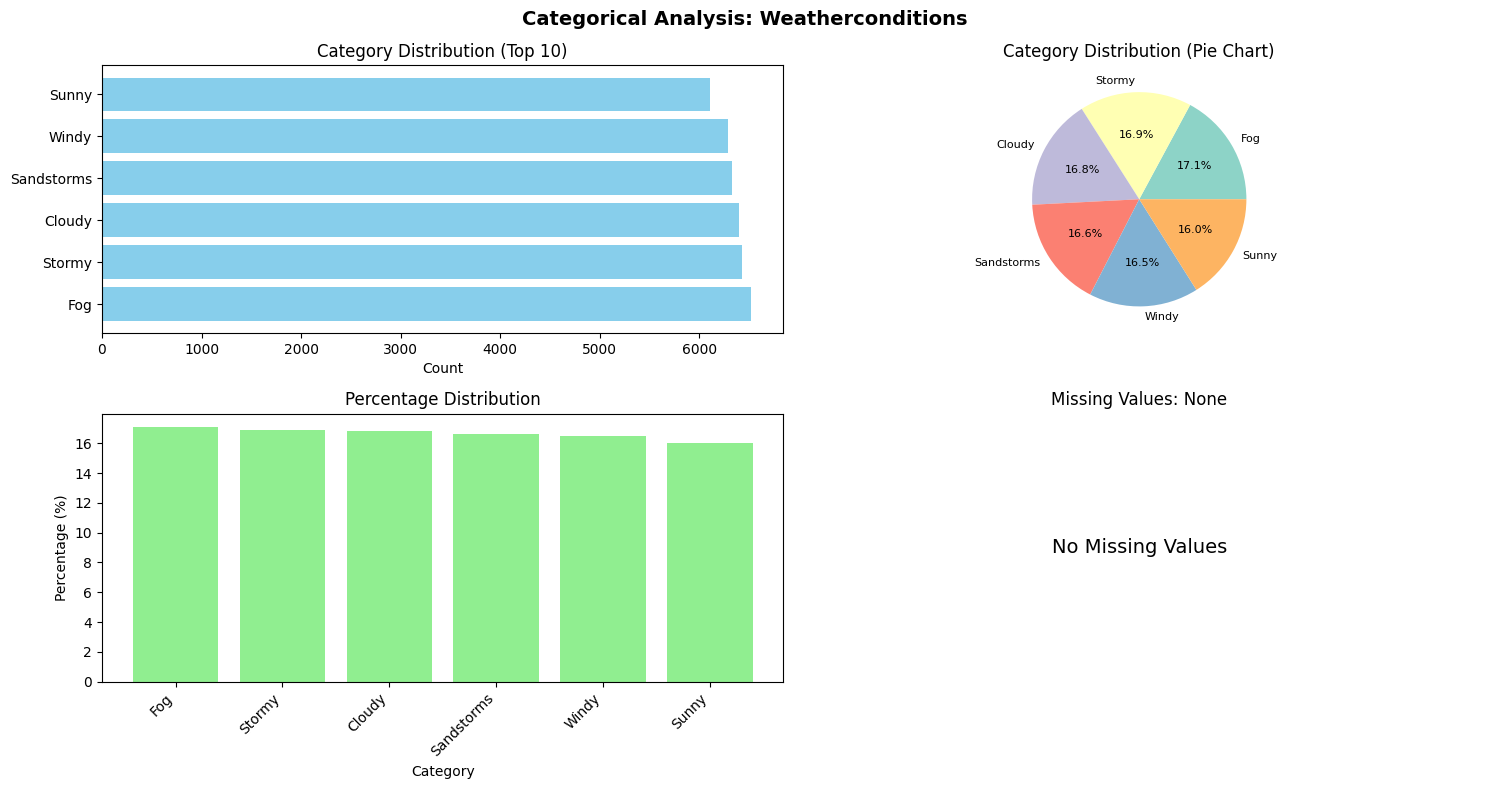


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: delivery_city

1. DESCRIPTIVE STATISTICS:
   - Unique values: 22
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
  Category  Count  Percentage
  Jabalpur   3137    8.241383
     Surat   2908    7.639765
 Hyderabad   2905    7.631883
Coimbatore   2897    7.610866
    Mumbai   2880    7.566204
 Bangalore   2878    7.560950
    Indore   2860    7.513661
      Pune   2839    7.458491
   Chennai   2835    7.447982
    Mysore   2715    7.132724
    Ranchi   2313    6.076608
  Vadodara   1432    3.762085
   Kolkata    647    1.699769
     Kochi    635    1.668243
  Ludhiana    627    1.647226
    Kanpur    616    1.618327
       Goa    547    1.437053
      Agra    513    1.347730
 Allahabad    511    1.342476
Aurangabad    502    1.318831
  Dehradun    436    1.145439
    Bhilai    431    1.132303

3. ANOMALIES/INSIGHTS:
   🔥 High cardinality: 22 unique values - may need fea

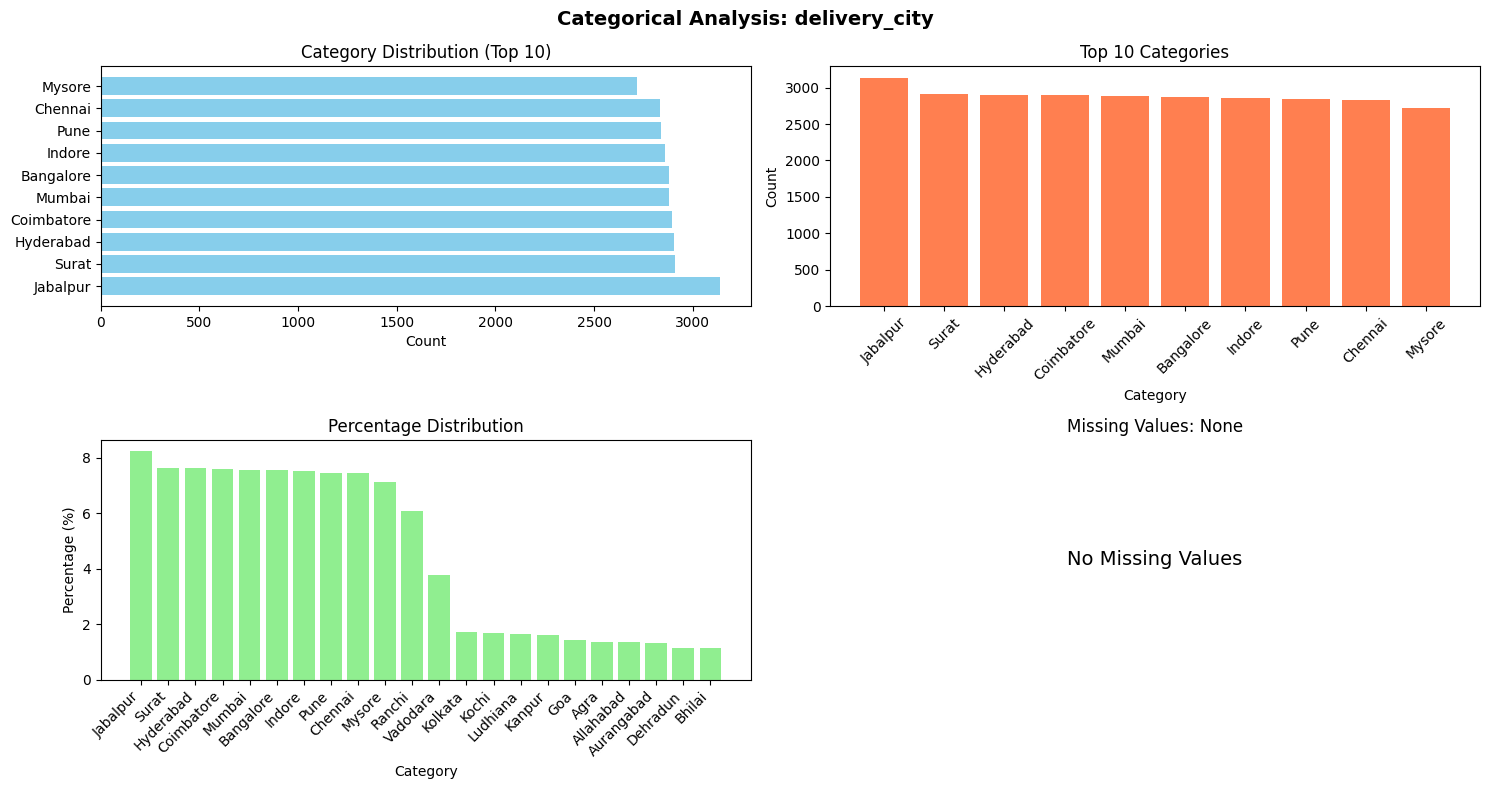


4. RECOMMENDATIONS:
   • High cardinality (22 categories):
     → Consider grouping rare categories into 'Other'
     → Use frequency or target encoding instead of one-hot encoding

--------------------------------------------------

ANALYZING: Delivery_person_Age

1. DESCRIPTIVE STATISTICS:
   - Unique values: 20
   - Missing values: 0 (0.00%)
   - Data type: int64

2. FREQUENCY DISTRIBUTION:
 Category  Count  Percentage
       35   2019    5.304224
       36   1992    5.233291
       30   1970    5.175494
       37   1967    5.167612
       32   1932    5.075662
       33   1926    5.059899
       38   1926    5.059899
       34   1917    5.036255
       22   1913    5.025746
       39   1902    4.996847
       24   1900    4.991593
       28   1891    4.967949
       29   1876    4.928541
       31   1861    4.889134
       26   1859    4.883880
       21   1854    4.870744
       27   1851    4.862863
       25   1847    4.852354
       20   1833    4.815574
       23   1828    4.

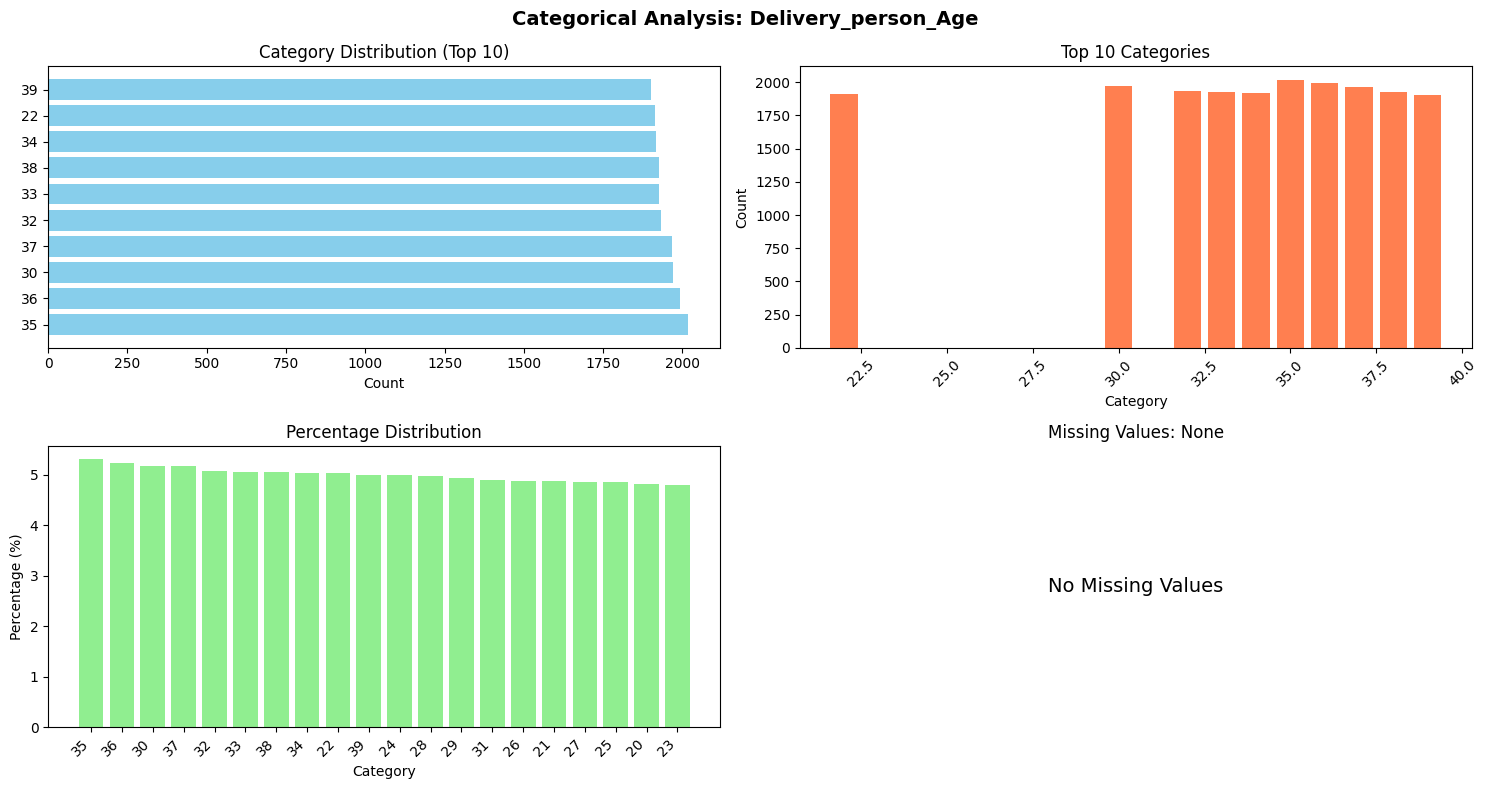


4. RECOMMENDATIONS:
   • High cardinality (20 categories):
     → Consider grouping rare categories into 'Other'
     → Use frequency or target encoding instead of one-hot encoding

--------------------------------------------------

ANALYZING: Festival

1. DESCRIPTIVE STATISTICS:
   - Unique values: 2
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
Category  Count  Percentage
      No  37299   97.990227
     Yes    765    2.009773

3. ANOMALIES/INSIGHTS:
   ⭐ Dominant category (>50%): No (98.0%)


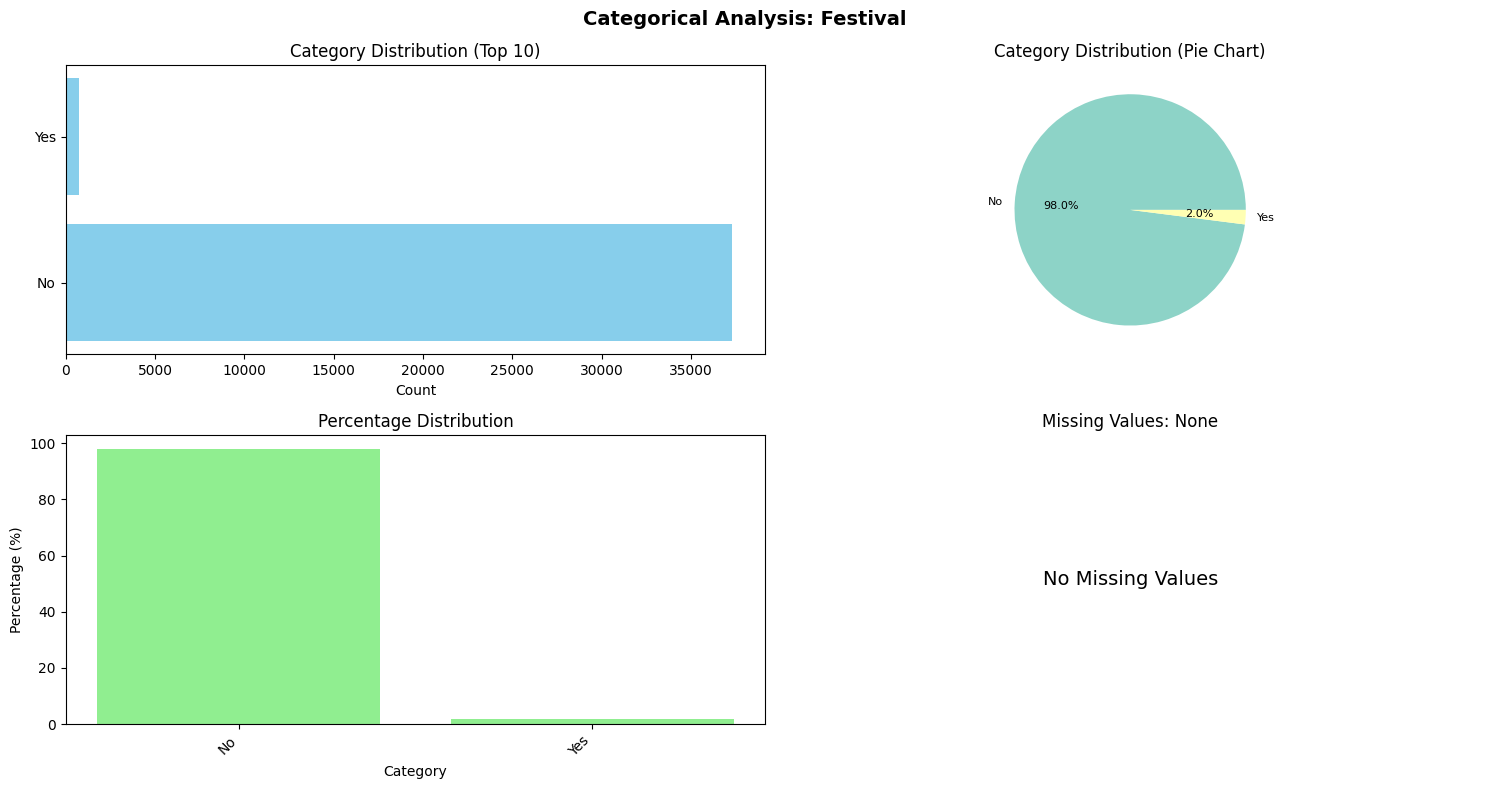


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: Type_of_vehicle

1. DESCRIPTIVE STATISTICS:
   - Unique values: 3
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
         Category  Count  Percentage
      motorcycle   22433   58.934952
         scooter   12598   33.096889
electric_scooter    3033    7.968159

3. ANOMALIES/INSIGHTS:
   ⭐ Dominant category (>50%): motorcycle  (58.9%)


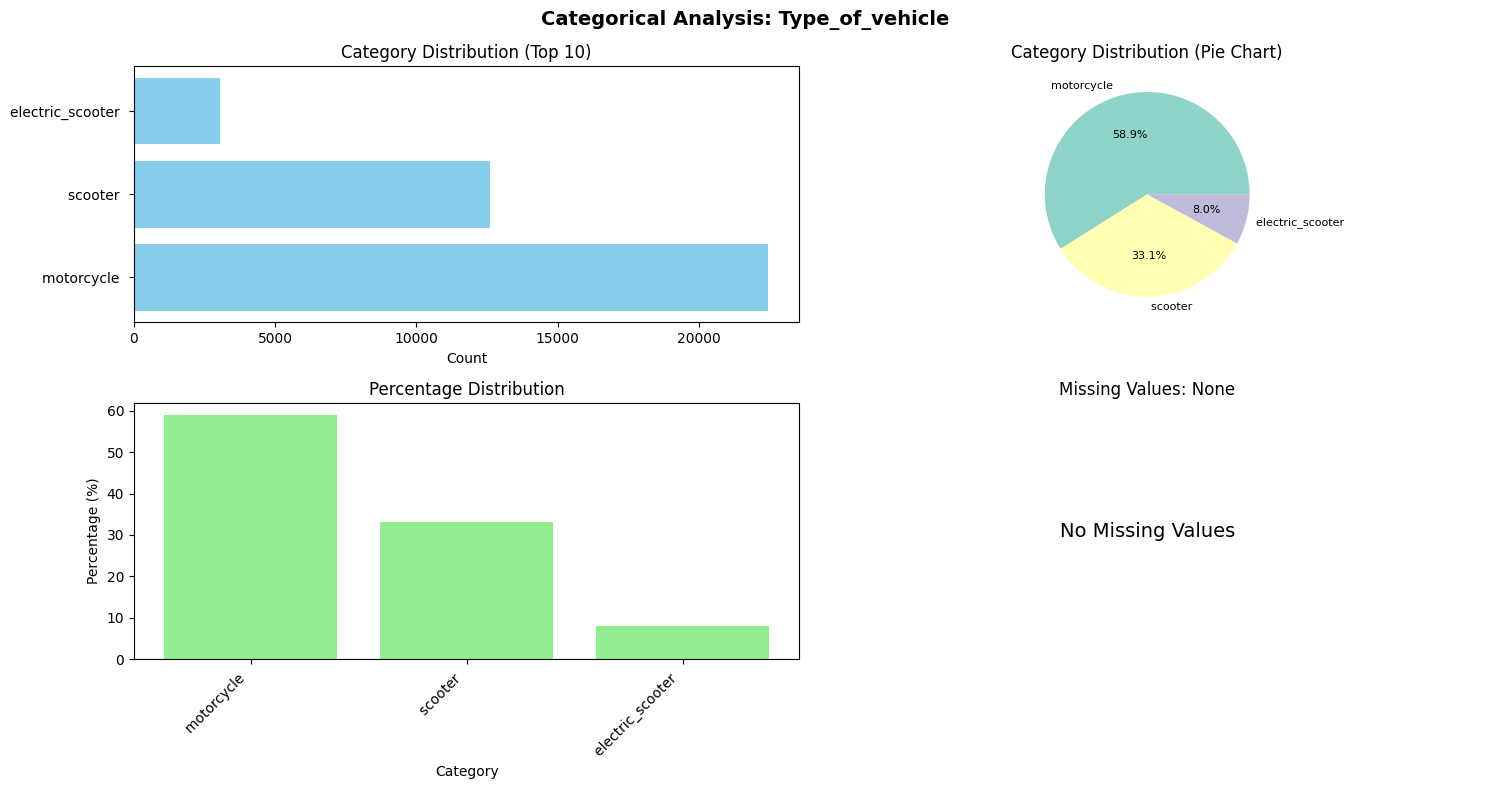


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: multiple_deliveries

1. DESCRIPTIVE STATISTICS:
   - Unique values: 4
   - Missing values: 0 (0.00%)
   - Data type: int64

2. FREQUENCY DISTRIBUTION:
 Category  Count  Percentage
        1  24095   63.301282
        0  11918   31.310425
        2   1745    4.584384
        3    306    0.803909

3. ANOMALIES/INSIGHTS:
   ⚠️ Rare categories (<1%): 1 categories
      [3]
   ⭐ Dominant category (>50%): 1 (63.3%)


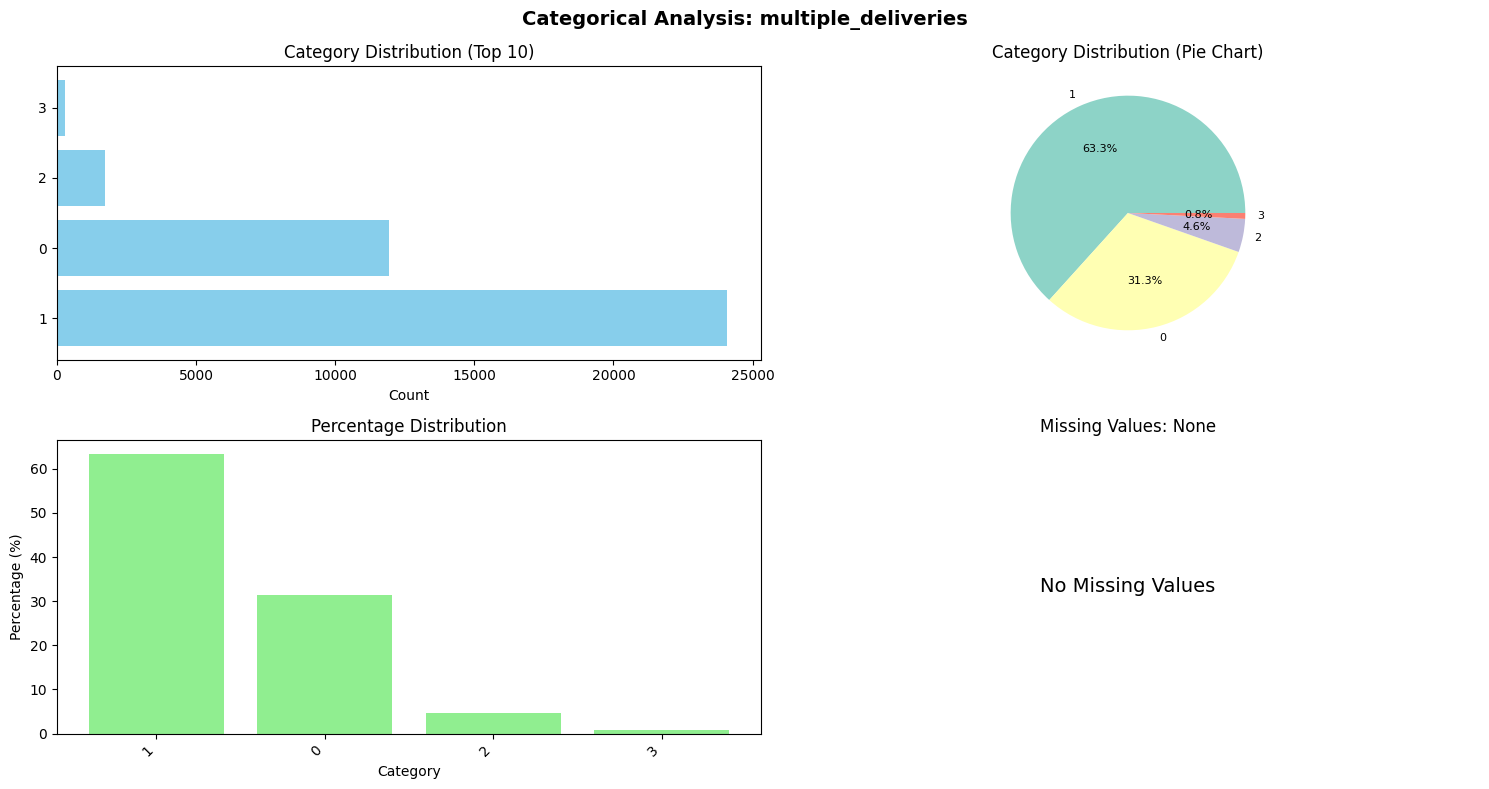


4. RECOMMENDATIONS:
   • Rare categories detected (1 categories with <1%):
     → Consider combining rare categories into 'Other' category

--------------------------------------------------

ANALYZING: Vehicle_condition

1. DESCRIPTIVE STATISTICS:
   - Unique values: 3
   - Missing values: 0 (0.00%)
   - Data type: int64

2. FREQUENCY DISTRIBUTION:
 Category  Count  Percentage
        0  12813   33.661728
        2  12633   33.188840
        1  12618   33.149433

3. ANOMALIES/INSIGHTS:


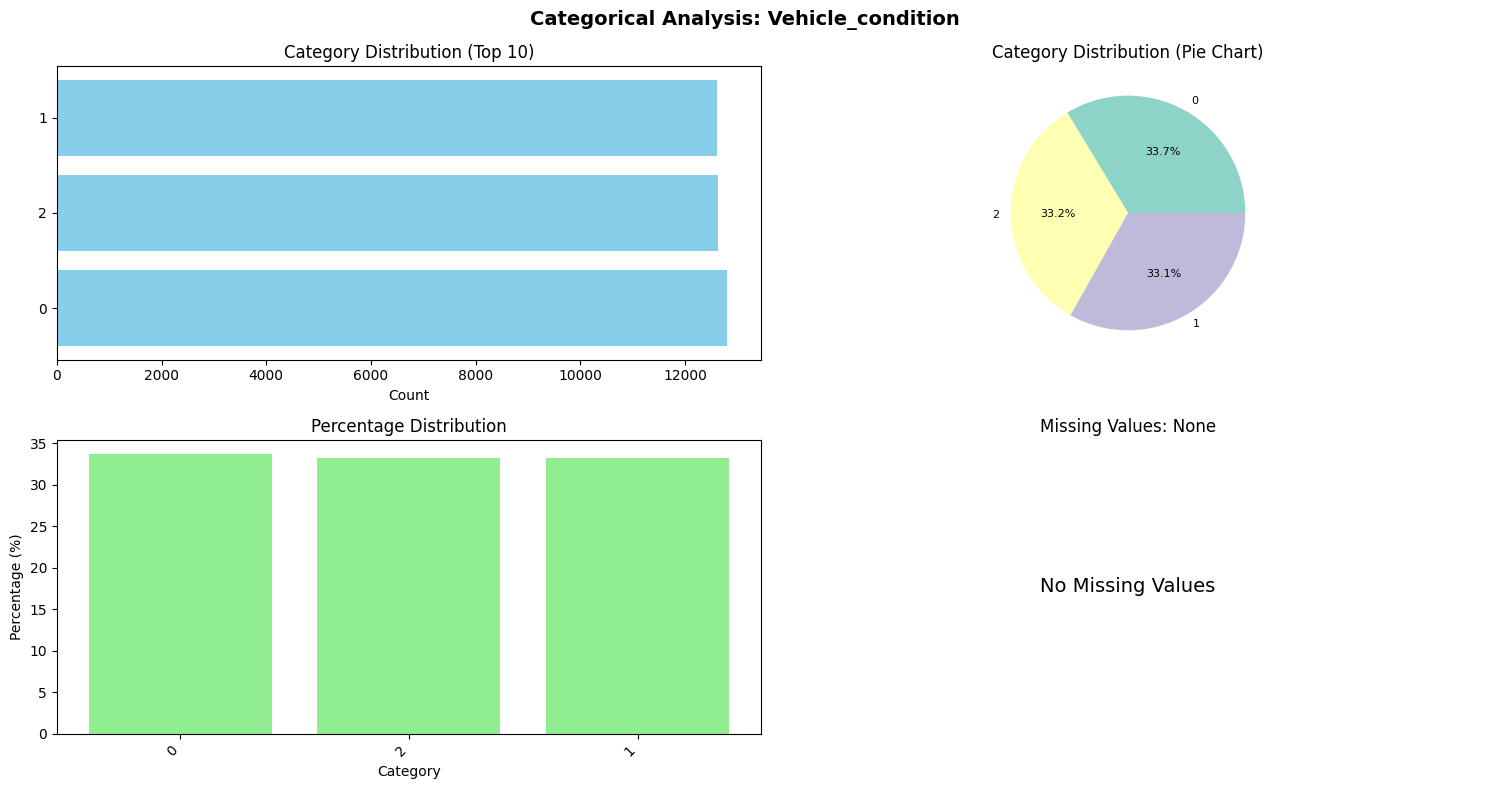


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: Road_traffic_density

1. DESCRIPTIVE STATISTICS:
   - Unique values: 4
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
Category  Count  Percentage
    Low   12831   33.709016
    Jam   12140   31.893653
 Medium    9326   24.500841
   High    3767    9.896490

3. ANOMALIES/INSIGHTS:


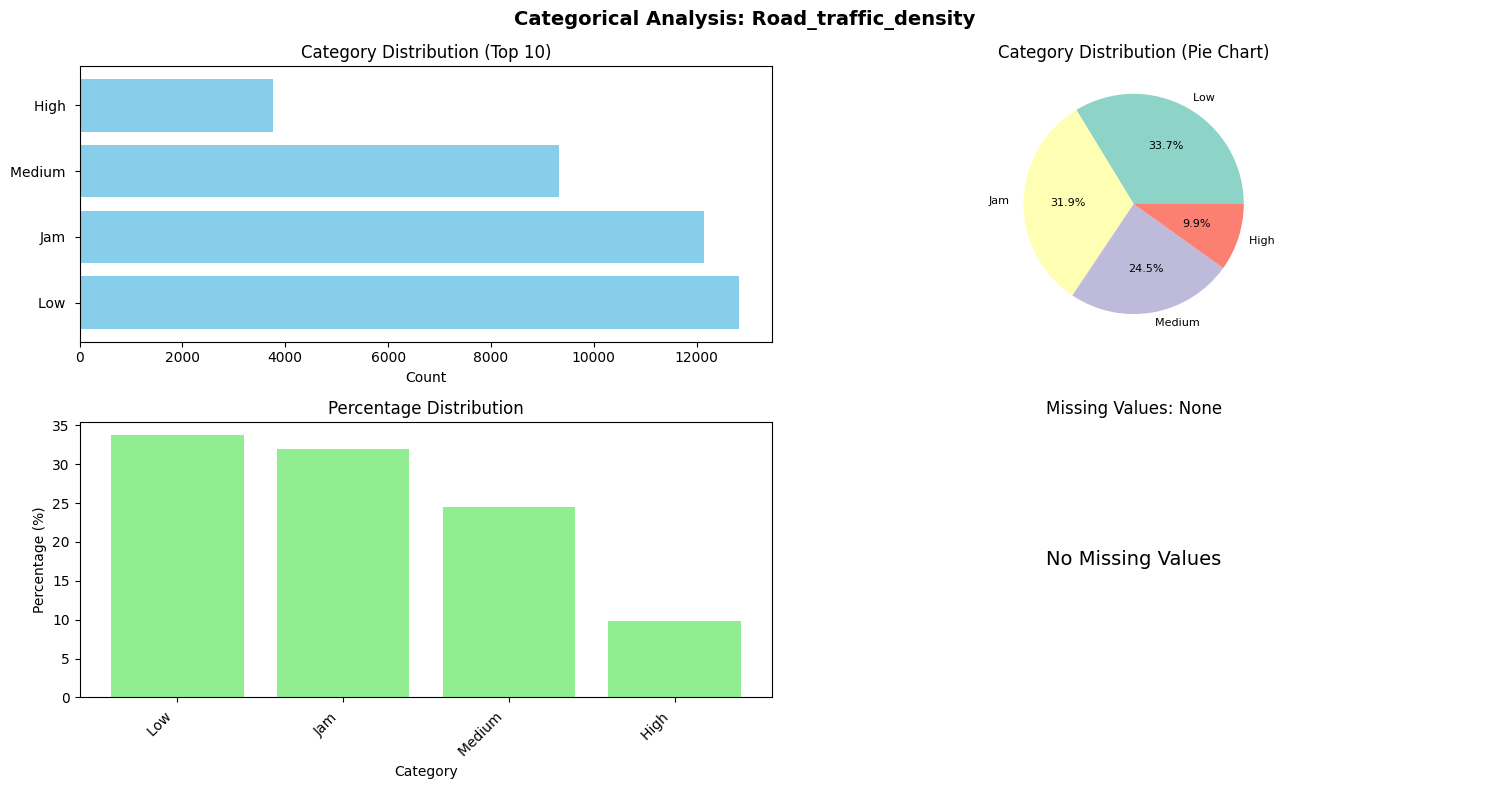


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: Type_of_order

1. DESCRIPTIVE STATISTICS:
   - Unique values: 4
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
Category  Count  Percentage
  Snack    9577   25.160256
   Meal    9574   25.152375
 Drinks    9514   24.994746
 Buffet    9399   24.692623

3. ANOMALIES/INSIGHTS:


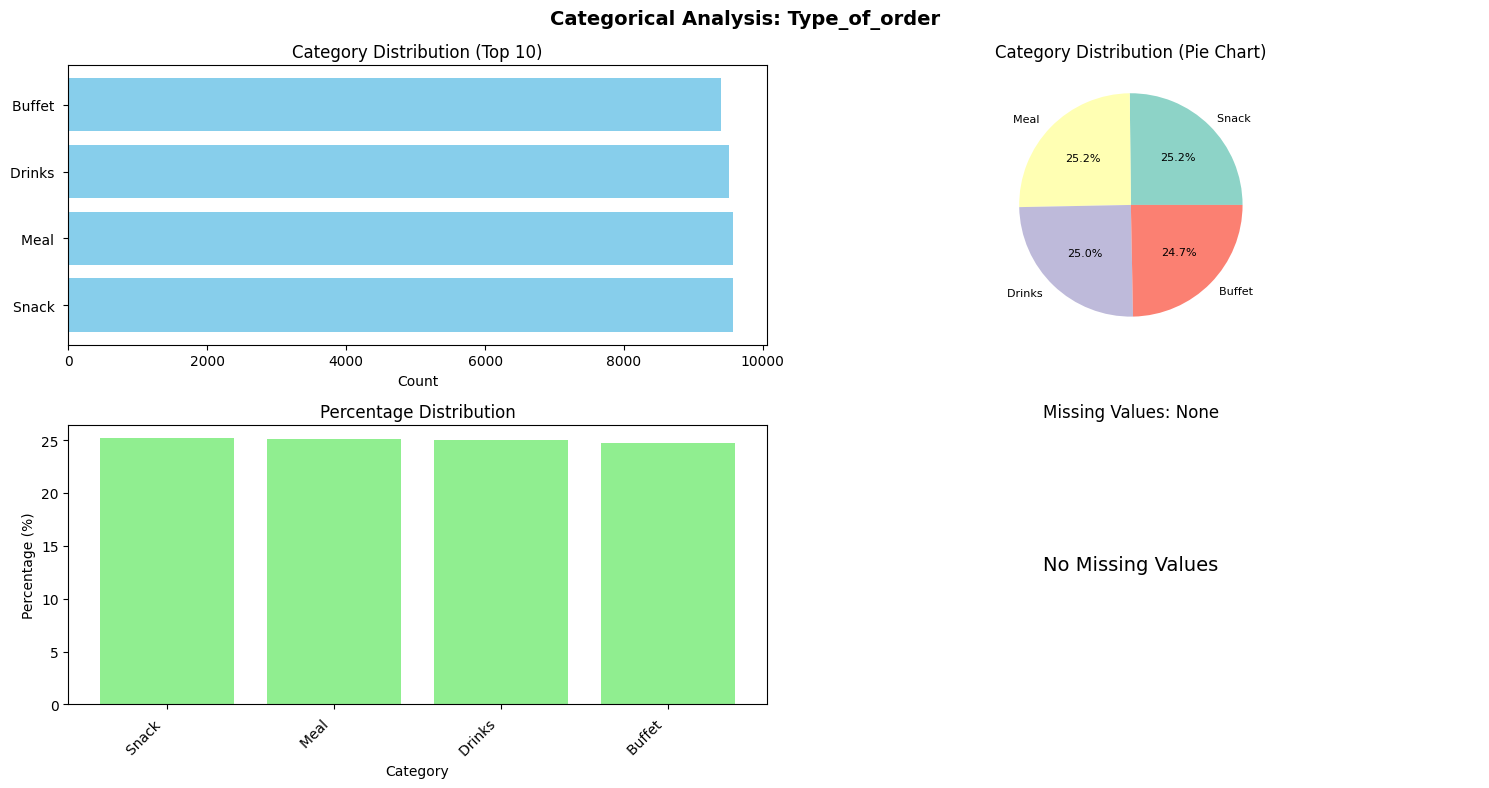


4. RECOMMENDATIONS:

--------------------------------------------------

OVERALL SUMMARY OF CATEGORICAL COLUMNS
              Column Data_Type  Unique_Values Most_Frequent  Most_Freq_Count  Most_Freq_Pct  Missing_Count  Missing_Pct  Has_Rare_Categories  Cardinality_Issue
   Weatherconditions    object              6           Fog             6518      17.123792              0          0.0                False              False
       delivery_city    object             22      Jabalpur             3137       8.241383              0          0.0                False               True
 Delivery_person_Age     int64             20            35             2019       5.304224              0          0.0                False               True
            Festival    object              2            No            37299      97.990227              0          0.0                False              False
     Type_of_vehicle    object              3   motorcycle             22433      58.93

,Column,Data_Type,Unique_Values,Most_Frequent,Most_Freq_Count,Most_Freq_Pct,Missing_Count,Missing_Pct,Has_Rare_Categories,Cardinality_Issue
0,Weatherconditions,object,6,Fog,6518,17.123792,0,0.0,False,False
1,delivery_city,object,22,Jabalpur,3137,8.241383,0,0.0,False,True
2,Delivery_person_Age,int64,20,35,2019,5.304224,0,0.0,False,True
3,Festival,object,2,No,37299,97.990227,0,0.0,False,False
4,Type_of_vehicle,object,3,motorcycle,22433,58.934952,0,0.0,False,False
5,multiple_deliveries,int64,4,1,24095,63.301282,0,0.0,True,False
6,Vehicle_condition,int64,3,0,12813,33.661728,0,0.0,False,False
7,Road_traffic_density,object,4,Low,12831,33.709016,0,0.0,False,False
8,Type_of_order,object,4,Snack,9577,25.160256,0,0.0,False,False


In [41]:
univariate_analysis_categorical(df, categorical_cols=cat, figsize=(15, 8))

## Bivariate

🎯 BIVARIATE ANALYSIS WITH TARGET: Time_taken(min)

📈 NUMERICAL FEATURES vs TARGET

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Delivery_person_Ratings → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


d:\Swiggy-Delivery-Time-Prediction\experiment\utils.py:504: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


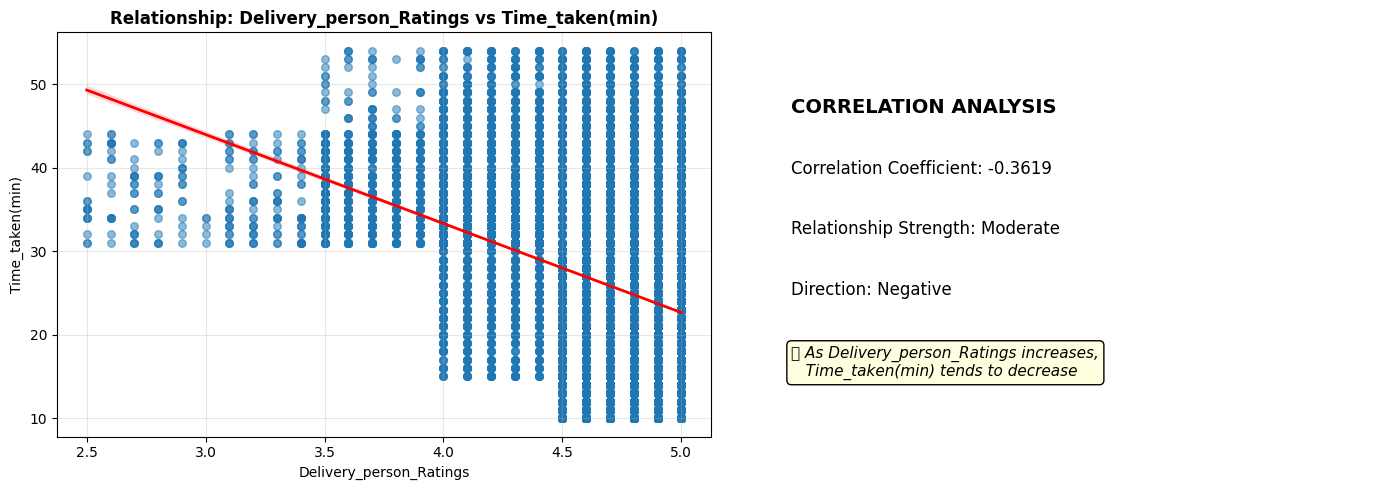


📊 Statistics:
   • Delivery_person_Ratings - Mean: 4.63, Std: 0.32
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: multiple_deliveries → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


d:\Swiggy-Delivery-Time-Prediction\experiment\utils.py:504: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


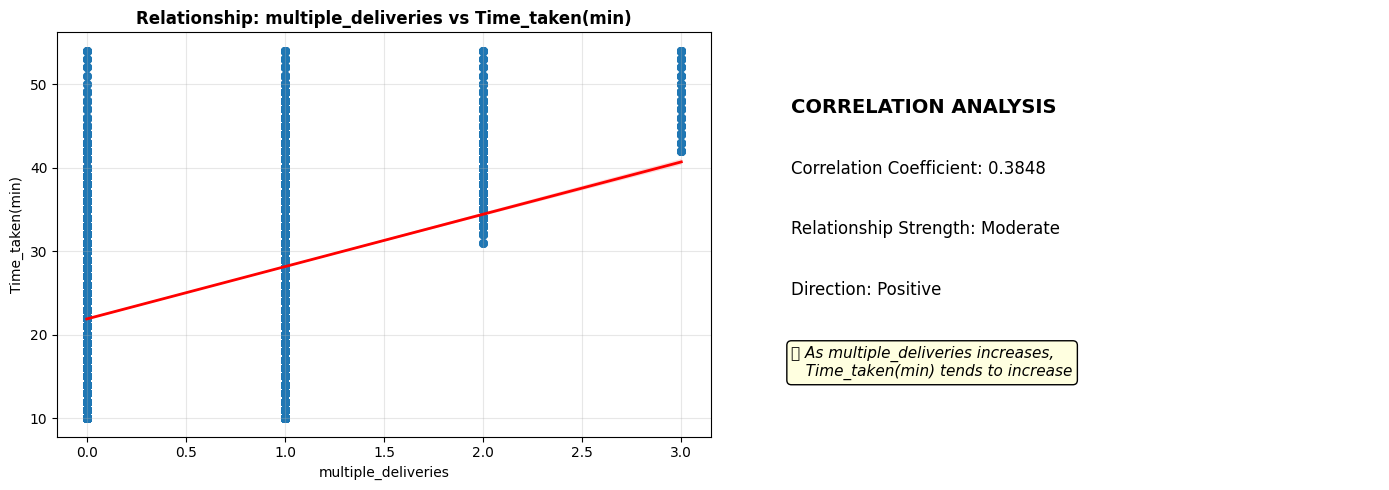


📊 Statistics:
   • multiple_deliveries - Mean: 0.75, Std: 0.57
   • Time_taken(min) - Mean: 26.58, Std: 9.33

📊 CATEGORICAL FEATURES vs TARGET

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Delivery_person_Age → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


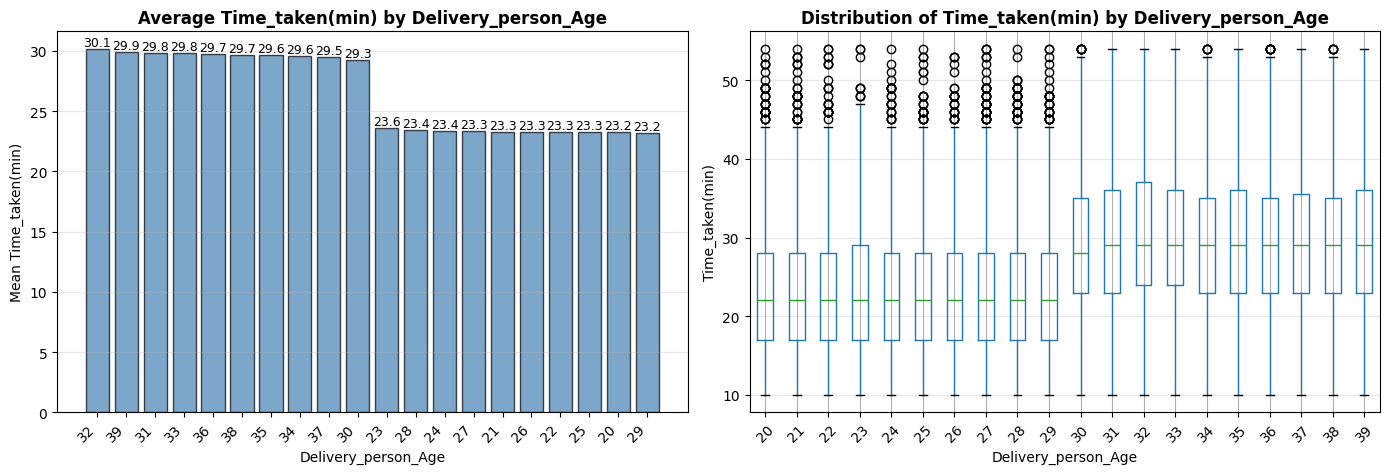


📊 Summary Statistics (sorted by mean Time_taken(min)):
                      mean  median  count   std
Delivery_person_Age                            
32                   30.12    29.0   1932  8.90
39                   29.87    29.0   1902  8.96
31                   29.81    29.0   1861  9.14
33                   29.80    29.0   1926  9.14
36                   29.71    29.0   1992  8.92
38                   29.67    29.0   1926  8.82
35                   29.64    29.0   2019  8.87
34                   29.60    29.0   1917  8.88
37                   29.49    29.0   1967  8.85
30                   29.27    28.0   1970  8.82
23                   23.61    22.0   1828  8.47
28                   23.45    22.0   1891  8.70
24                   23.38    22.0   1900  8.66
27                   23.32    22.0   1851  8.72
21                   23.29    22.0   1854  8.62
26                   23.29    22.0   1859  8.52
22                   23.28    22.0   1913  8.42
25                   23.26    22

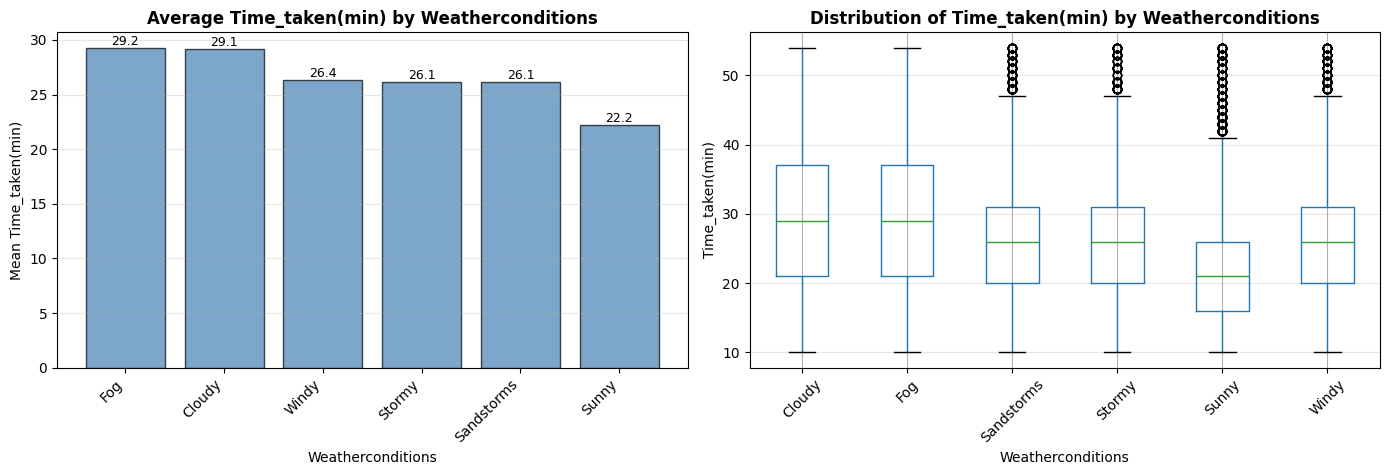


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count    std
Weatherconditions                             
Fog                29.23    29.0   6518  10.10
Cloudy             29.15    29.0   6393   9.97
Windy              26.37    26.0   6289   8.54
Stormy             26.14    26.0   6431   8.43
Sandstorms         26.13    26.0   6326   8.57
Sunny              22.18    21.0   6107   8.35

💡 Key Insight:
   • Best category: 'Fog' (Avg Time_taken(min): 29.23)
   • Worst category: 'Sunny' (Avg Time_taken(min): 22.18)
   • Difference: 7.05

📈 Statistical Significance (ANOVA):
   • F-statistic: 511.1045
   • p-value: 0.0000
   • ✅ Weatherconditions has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Road_traffic_density → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


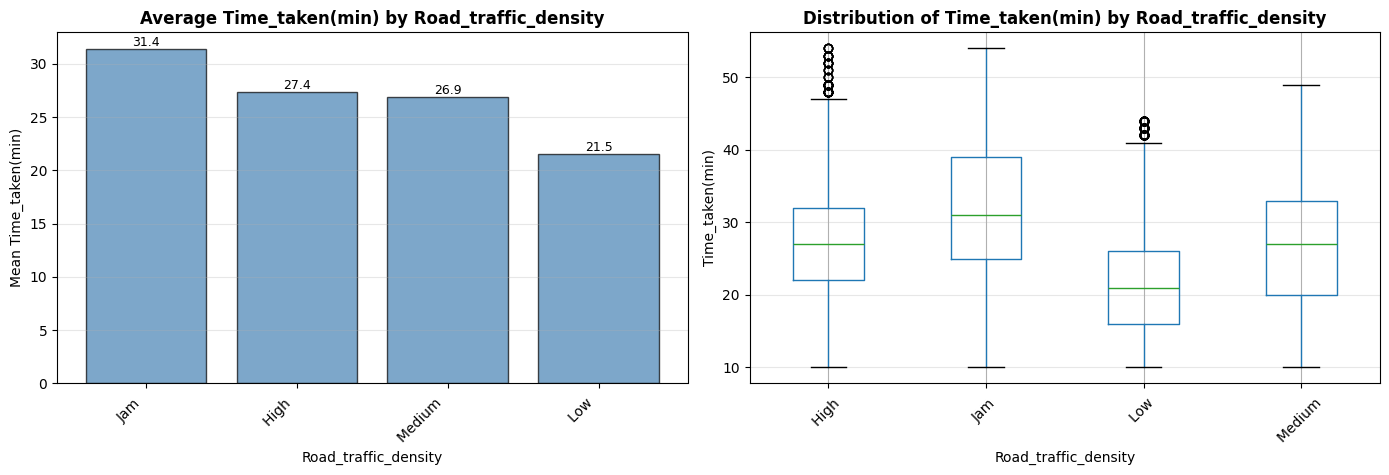


📊 Summary Statistics (sorted by mean Time_taken(min)):
                       mean  median  count   std
Road_traffic_density                            
Jam                   31.40    31.0  12140  9.84
High                  27.39    27.0   3767  8.31
Medium                26.93    27.0   9326  8.47
Low                   21.51    21.0  12831  6.80

💡 Key Insight:
   • Best category: 'Jam ' (Avg Time_taken(min): 31.40)
   • Worst category: 'Low ' (Avg Time_taken(min): 21.51)
   • Difference: 9.89

📈 Statistical Significance (ANOVA):
   • F-statistic: 2895.9441
   • p-value: 0.0000
   • ✅ Road_traffic_density has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Vehicle_condition → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


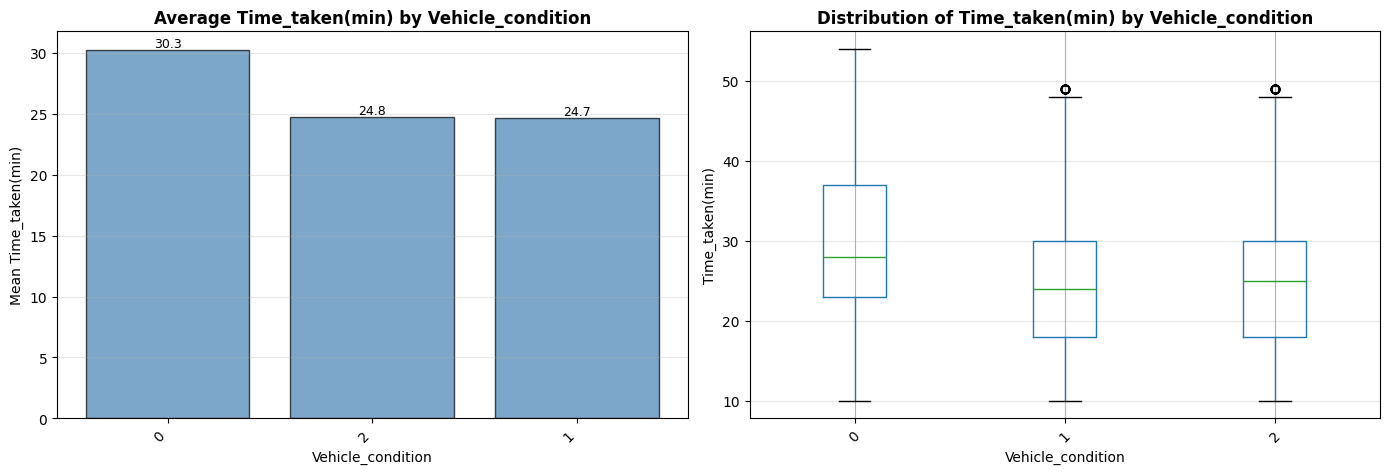


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count   std
Vehicle_condition                            
0                  30.26    28.0  12813  9.55
2                  24.76    25.0  12633  8.61
1                  24.66    24.0  12618  8.66

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 30.26)
   • Worst category: '1' (Avg Time_taken(min): 24.66)
   • Difference: 5.60

📈 Statistical Significance (ANOVA):
   • F-statistic: 1635.4537
   • p-value: 0.0000
   • ✅ Vehicle_condition has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Type_of_order → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


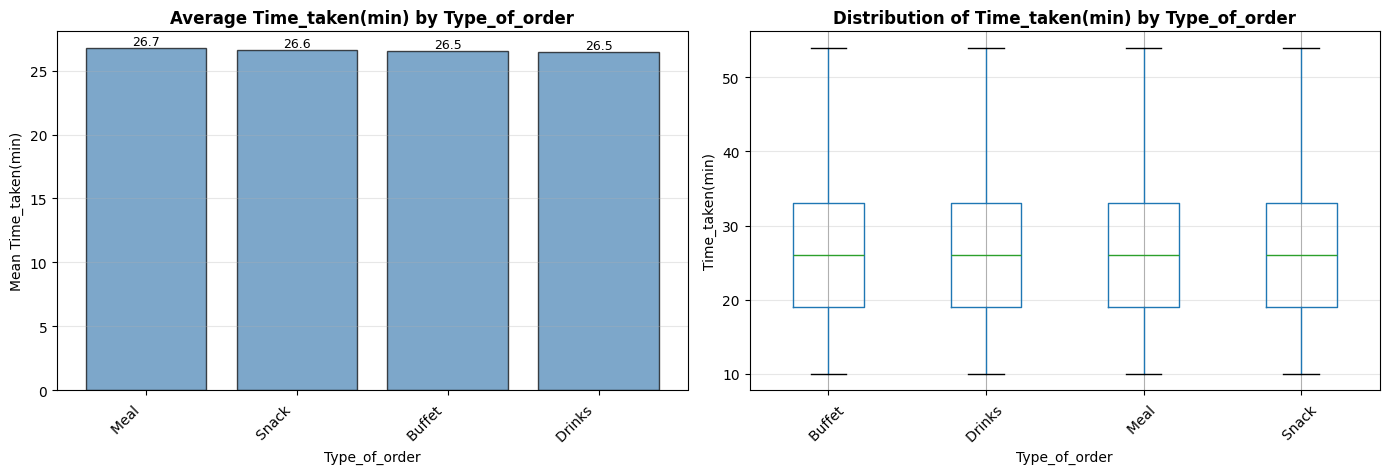


📊 Summary Statistics (sorted by mean Time_taken(min)):
                mean  median  count   std
Type_of_order                            
Meal           26.74    26.0   9574  9.38
Snack          26.58    26.0   9577  9.35
Buffet         26.50    26.0   9399  9.34
Drinks         26.48    26.0   9514  9.24

💡 Key Insight:
   • Best category: 'Meal ' (Avg Time_taken(min): 26.74)
   • Worst category: 'Drinks ' (Avg Time_taken(min): 26.48)
   • Difference: 0.26

📈 Statistical Significance (ANOVA):
   • F-statistic: 1.5656
   • p-value: 0.1954
   • ❌ Type_of_order does NOT have significant impact on Time_taken(min)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Type_of_vehicle → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


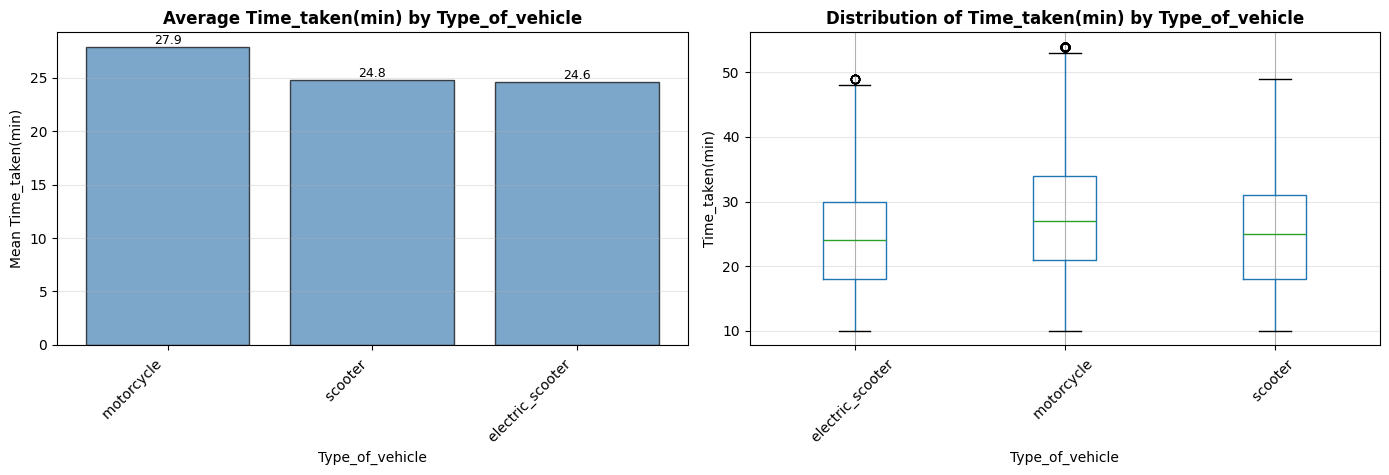


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count   std
Type_of_vehicle                              
motorcycle         27.85    27.0  22433  9.59
scooter            24.78    25.0  12598  8.64
electric_scooter   24.59    24.0   3033  8.58

💡 Key Insight:
   • Best category: 'motorcycle ' (Avg Time_taken(min): 27.85)
   • Worst category: 'electric_scooter ' (Avg Time_taken(min): 24.59)
   • Difference: 3.26

📈 Statistical Significance (ANOVA):
   • F-statistic: 524.8602
   • p-value: 0.0000
   • ✅ Type_of_vehicle has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Festival → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


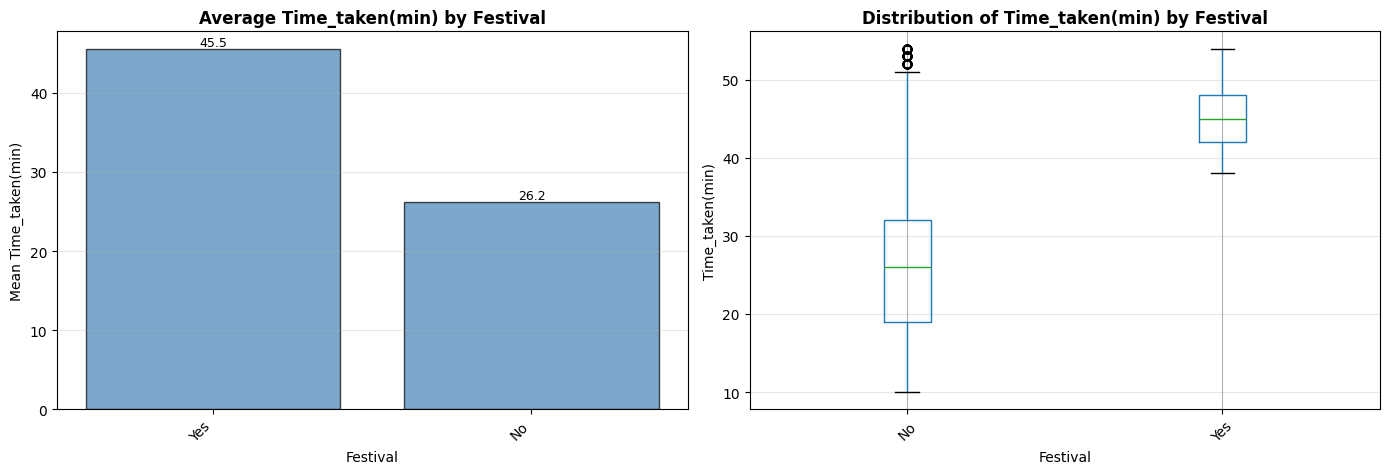


📊 Summary Statistics (sorted by mean Time_taken(min)):
           mean  median  count   std
Festival                            
Yes       45.50    45.0    765  4.02
No        26.19    26.0  37299  9.00

💡 Key Insight:
   • Best category: 'Yes' (Avg Time_taken(min): 45.50)
   • Worst category: 'No' (Avg Time_taken(min): 26.19)
   • Difference: 19.31

📈 Statistical Significance (ANOVA):
   • F-statistic: 3505.2344
   • p-value: 0.0000
   • ✅ Festival has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: delivery_city → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


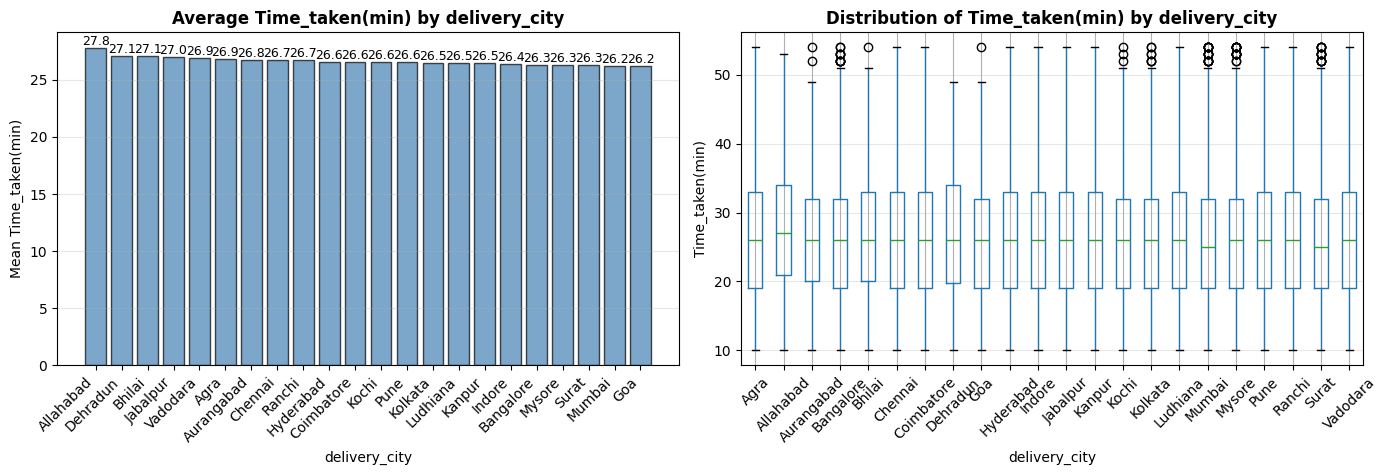


📊 Summary Statistics (sorted by mean Time_taken(min)):
                mean  median  count   std
delivery_city                            
Allahabad      27.77    27.0    511  9.56
Dehradun       27.11    26.0    436  9.57
Bhilai         27.08    26.0    431  9.34
Jabalpur       27.00    26.0   3137  9.54
Vadodara       26.91    26.0   1432  9.46
Agra           26.86    26.0    513  9.41
Aurangabad     26.78    26.0    502  8.93
Chennai        26.74    26.0   2835  9.35
Ranchi         26.73    26.0   2313  9.48
Hyderabad      26.60    26.0   2905  9.41
Coimbatore     26.58    26.0   2897  9.31
Kochi          26.58    26.0    635  9.37
Pune           26.57    26.0   2839  9.34
Kolkata        26.51    26.0    647  9.25
Ludhiana       26.51    26.0    627  9.50
Kanpur         26.47    26.0    616  9.35
Indore         26.41    26.0   2860  9.30
Bangalore      26.34    26.0   2878  9.13
Mysore         26.30    26.0   2715  9.41
Surat          26.30    25.0   2908  9.09
Mumbai         26.25

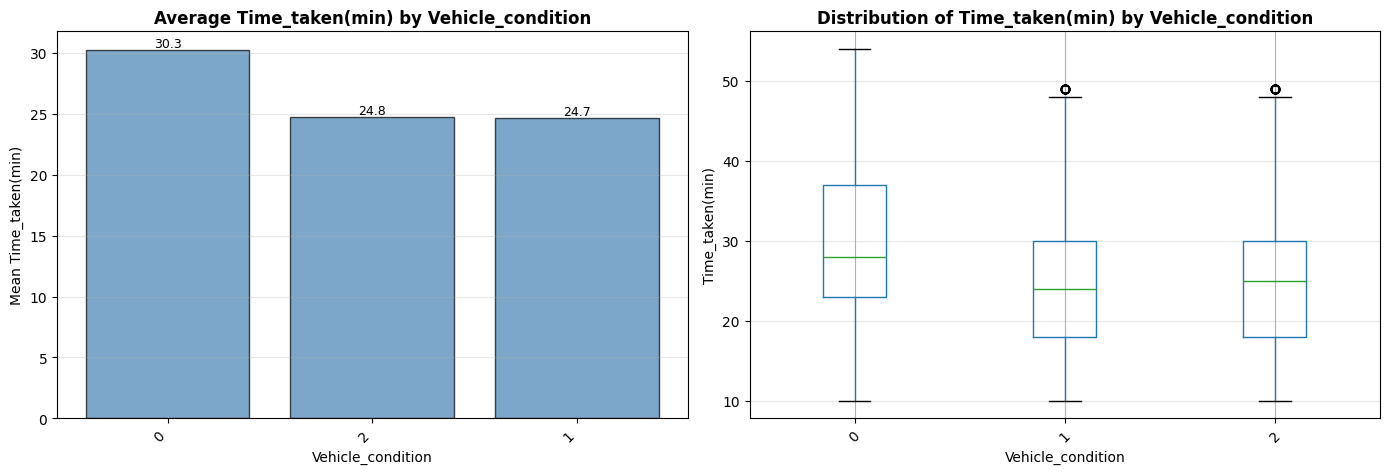


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count   std
Vehicle_condition                            
0                  30.26    28.0  12813  9.55
2                  24.76    25.0  12633  8.61
1                  24.66    24.0  12618  8.66

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 30.26)
   • Worst category: '1' (Avg Time_taken(min): 24.66)
   • Difference: 5.60

📈 Statistical Significance (ANOVA):
   • F-statistic: 1635.4537
   • p-value: 0.0000
   • ✅ Vehicle_condition has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: multiple_deliveries → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


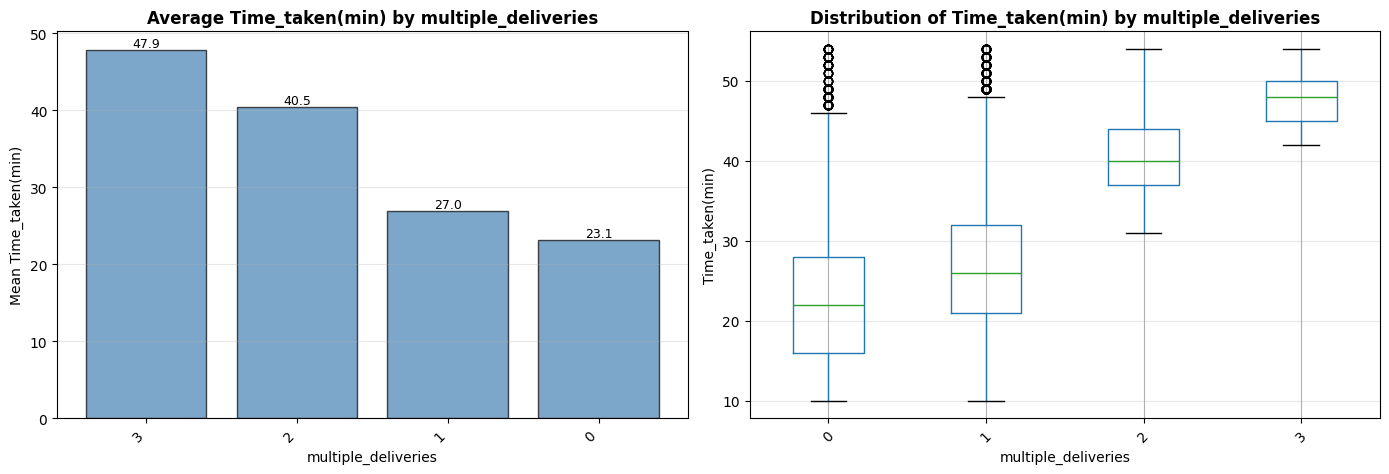


📊 Summary Statistics (sorted by mean Time_taken(min)):
                      mean  median  count   std
multiple_deliveries                            
3                    47.88    48.0    306  3.51
2                    40.47    40.0   1745  4.90
1                    27.00    26.0  24095  8.49
0                    23.14    22.0  11918  8.74

💡 Key Insight:
   • Best category: '3' (Avg Time_taken(min): 47.88)
   • Worst category: '0' (Avg Time_taken(min): 23.14)
   • Difference: 24.74

📈 Statistical Significance (ANOVA):
   • F-statistic: 2924.9274
   • p-value: 0.0000
   • ✅ multiple_deliveries has SIGNIFICANT impact on Time_taken(min) (p < 0.05)


In [42]:
bivariate_analysis(df, num, cat, tgt)

## Multi-Variate


Multivariate EDA - Target: Time_taken(min)

📈 Numerical Feature Correlations:
  Delivery_person_Ratings: -0.362
  multiple_deliveries : +0.385


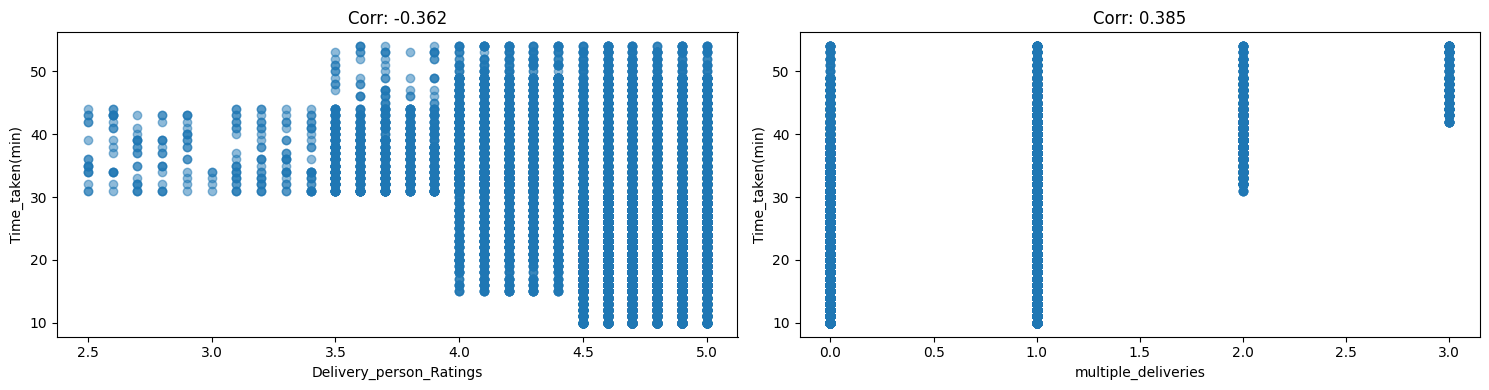


📊 Categorical Feature Impact:

  → Delivery_person_Age:
      32: 30.12
      39: 29.87
      31: 29.81

  → Weatherconditions:
      Fog: 29.23
      Cloudy: 29.15
      Windy: 26.37

  → Road_traffic_density:
      Jam : 31.40
      High : 27.39
      Medium : 26.93

✅ Analysis complete!


In [43]:
quick_multivariate_eda(df, num, cat, tgt)

## Mix cols

In [44]:
df[mix].sample(5)

,Order_Date,Time_Orderd,Time_Order_picked
7962,26-03-2022,08:30:00,08:45:00
12162,26-03-2022,23:15:00,23:30:00
23630,17-02-2022,18:00:00,18:10:00
833,27-03-2022,19:50:00,20:05:00
9662,02-04-2022,19:15:00,19:25:00


In [45]:
from datetime import datetime

# Step 1: Convert Order_Date to datetime (DD-MM-YYYY format)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

# Step 2: Create full datetime for order and pickup
df['Order_Datetime'] = pd.to_datetime(
    df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time_Orderd']
)

df['Pickup_Datetime'] = pd.to_datetime(
    df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Time_Order_picked']
)

# Step 3: Handle cases where pickup is next day (if pickup time < order time)
mask = df['Pickup_Datetime'] < df['Order_Datetime']
df.loc[mask, 'Pickup_Datetime'] += pd.Timedelta(days=1)

# Step 4: Calculate preparation time (time between order and pickup)
df['preparation_time_minutes'] = (
    df['Pickup_Datetime'] - df['Order_Datetime']
).dt.total_seconds() / 60

# Step 5: Extract features from Order_Date
df['order_day'] = df['Order_Date'].dt.day
df['order_month'] = df['Order_Date'].dt.month
df['order_year'] = df['Order_Date'].dt.year
df['order_dayofweek'] = df['Order_Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['order_day_name'] = df['Order_Date'].dt.day_name()
df['is_weekend'] = (df['order_dayofweek'] >= 5).astype(int)

# Step 6: Extract features from Time_Orderd
df['order_hour'] = pd.to_datetime(df['Time_Orderd']).dt.hour
df['order_minute'] = pd.to_datetime(df['Time_Orderd']).dt.minute

# Step 7: Time of day categories
def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Late Night'
    else:
        return 'Night'

df['time_category'] = df['order_hour'].apply(get_time_category)

# Step 8: Special flags
df['is_peak_hour'] = df['order_hour'].isin([12, 13, 19, 20, 21]).astype(int)
df['is_late_night'] = df['order_hour'].between(22, 23).astype(int)
df['is_rush_hour'] = df['order_hour'].isin([8, 9, 17, 18]).astype(int)


# Step 9: Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['order_month'].apply(get_season)

C:\Users\iampr\AppData\Local\Temp\ipykernel_16388\3066837209.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_hour'] = pd.to_datetime(df['Time_Orderd']).dt.hour
C:\Users\iampr\AppData\Local\Temp\ipykernel_16388\3066837209.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_minute'] = pd.to_datetime(df['Time_Orderd']).dt.minute


In [46]:
df.drop(columns=mix, inplace=True)

In [47]:
df.drop(columns=['Order_Datetime', 'Pickup_Datetime'], inplace=True)

## EDA (ROUND 2)

In [48]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'Time_taken(min)',
       'delivery_city', 'preparation_time_minutes', 'order_day', 'order_month',
       'order_year', 'order_dayofweek', 'order_day_name', 'is_weekend',
       'order_hour', 'order_minute', 'time_category', 'is_peak_hour',
       'is_late_night', 'is_rush_hour', 'season'],
      dtype='object')

In [49]:
df.sample(5)

,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,Time_taken(min),...,order_dayofweek,order_day_name,is_weekend,order_hour,order_minute,time_category,is_peak_hour,is_late_night,is_rush_hour,season
8130,33,5.0,Sunny,Low,1,Meal,scooter,0,No,19,...,3,Thursday,0,23,20,Late Night,0,1,0,Spring
29307,38,4.9,Stormy,Low,2,Drinks,motorcycle,0,No,18,...,4,Friday,0,23,0,Late Night,0,1,0,Spring
1580,33,4.7,Stormy,Medium,2,Snack,scooter,1,No,26,...,3,Thursday,0,17,25,Evening,0,0,1,Spring
13122,22,4.8,Cloudy,Low,1,Snack,motorcycle,0,No,18,...,5,Saturday,1,10,20,Morning,0,0,0,Spring
1031,22,4.9,Fog,Jam,1,Meal,motorcycle,1,No,25,...,6,Sunday,1,20,35,Evening,1,0,0,Winter


In [55]:
num1 = ['Delivery_person_Age','Delivery_person_Ratings','Vehicle_condition','multiple_deliveries', 'preparation_time_minutes', 'order_day', 'order_month','order_dayofweek','order_hour', 'order_minute']
num_new = [col for col in num1 if col not in num]

# Get categorical columns (cat1) as all columns except those in num1
cat1 = [col for col in df.columns if col not in num1]
cat_new = [col for col in cat1 if col not in cat]

In [56]:
num_new

['Delivery_person_Age',
 'Vehicle_condition',
 'preparation_time_minutes',
 'order_day',
 'order_month',
 'order_dayofweek',
 'order_hour',
 'order_minute']

In [57]:
cat_new

['Time_taken(min)',
 'order_year',
 'order_day_name',
 'is_weekend',
 'time_category',
 'is_peak_hour',
 'is_late_night',
 'is_rush_hour',
 'season']

🎯 BIVARIATE ANALYSIS WITH TARGET: Time_taken(min)

📈 NUMERICAL FEATURES vs TARGET

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Delivery_person_Age → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


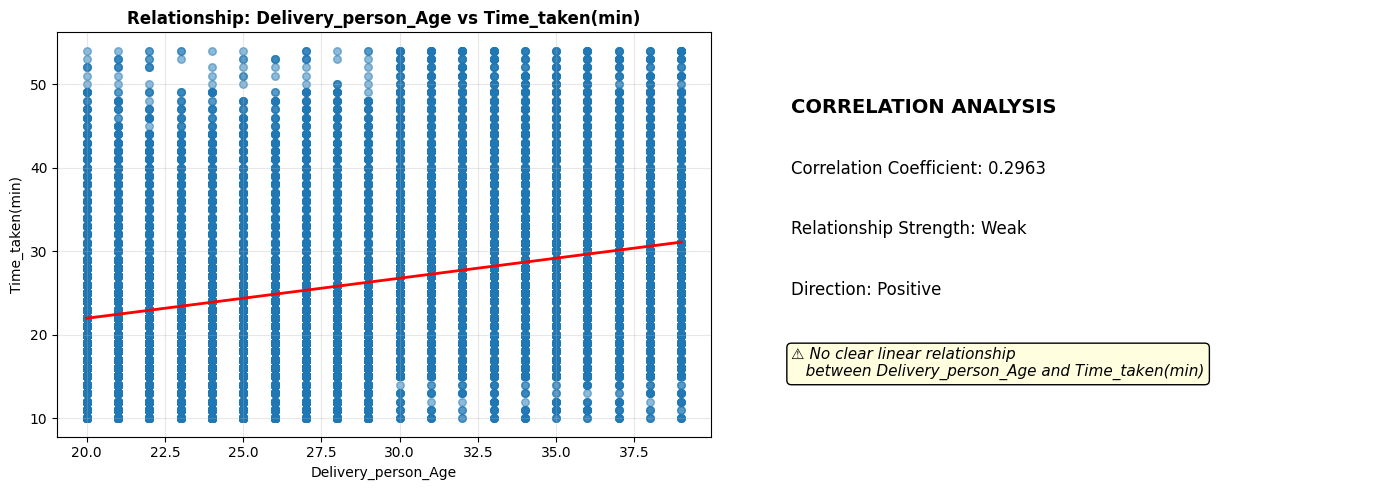


📊 Statistics:
   • Delivery_person_Age - Mean: 29.61, Std: 5.76
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Vehicle_condition → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


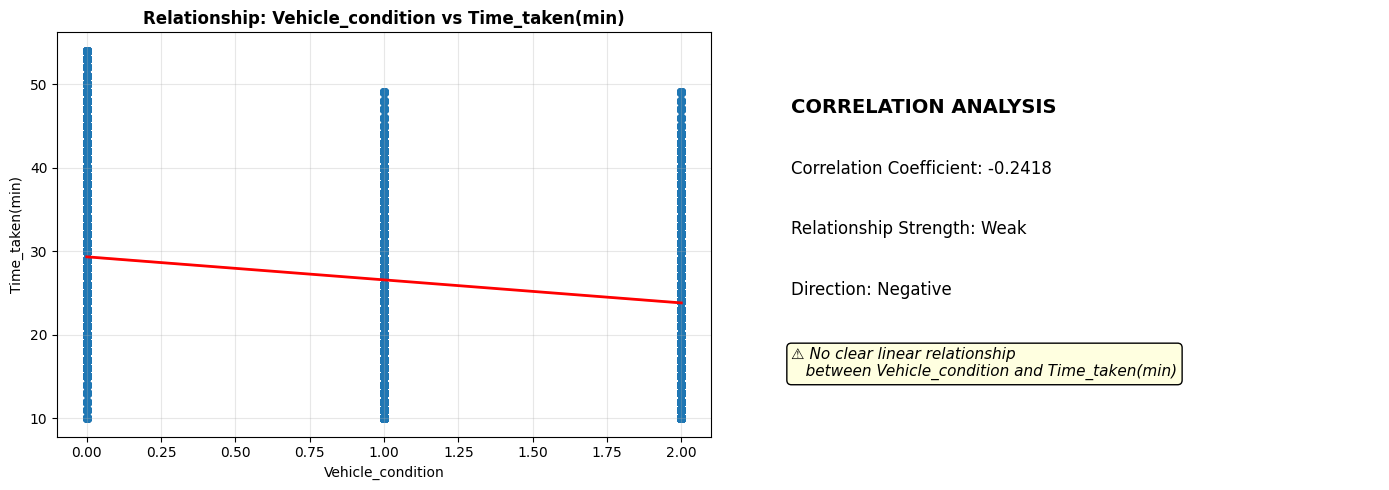


📊 Statistics:
   • Vehicle_condition - Mean: 1.00, Std: 0.82
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: preparation_time_minutes → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


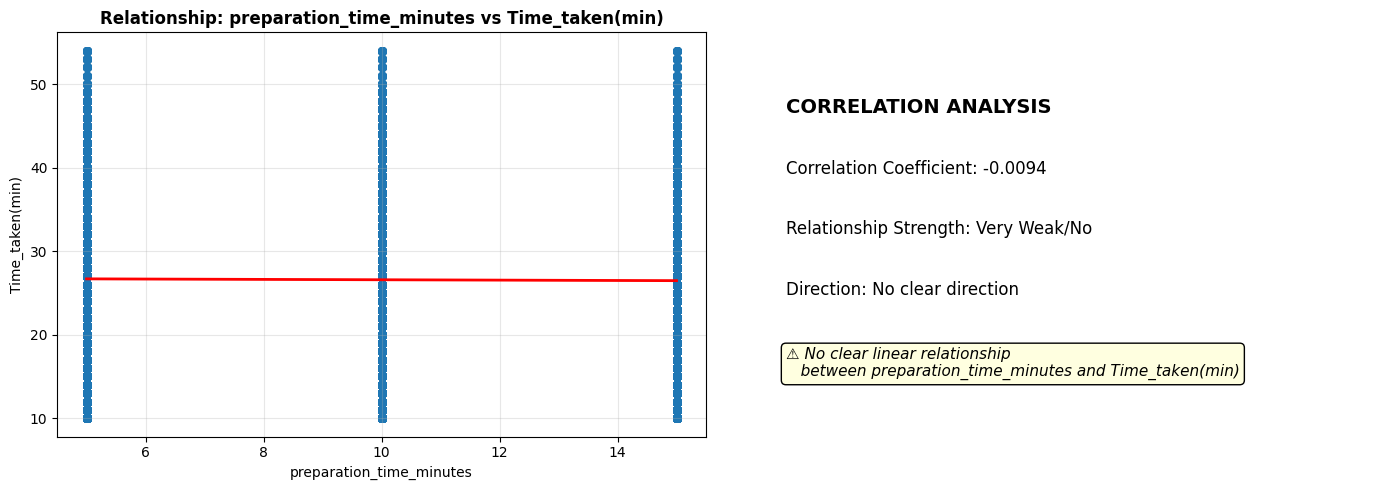


📊 Statistics:
   • preparation_time_minutes - Mean: 9.98, Std: 4.09
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_day → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


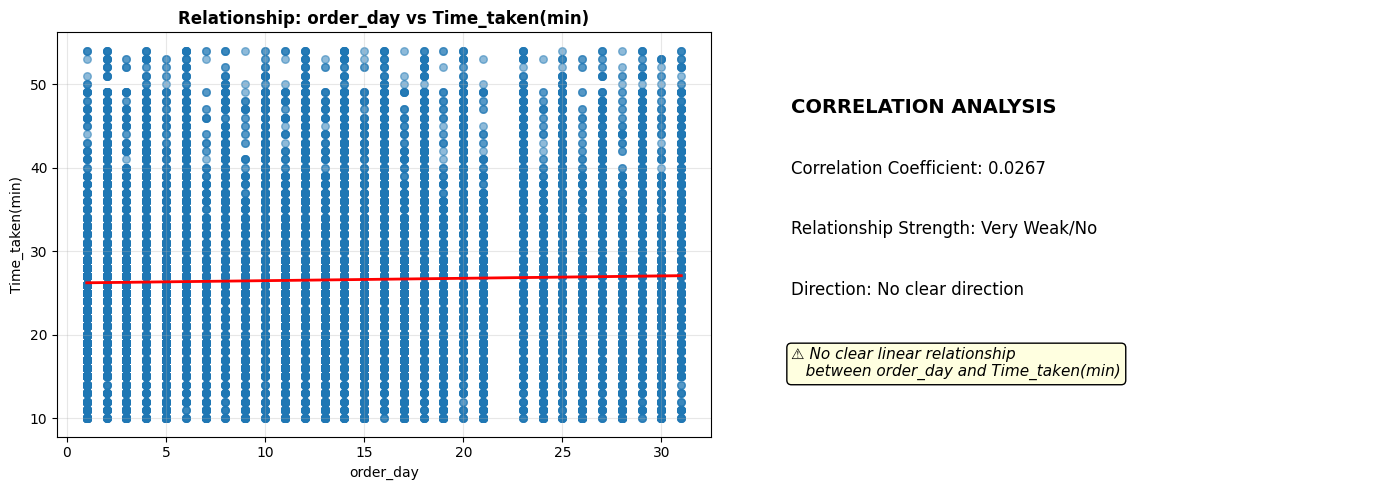


📊 Statistics:
   • order_day - Mean: 13.79, Std: 8.78
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_month → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


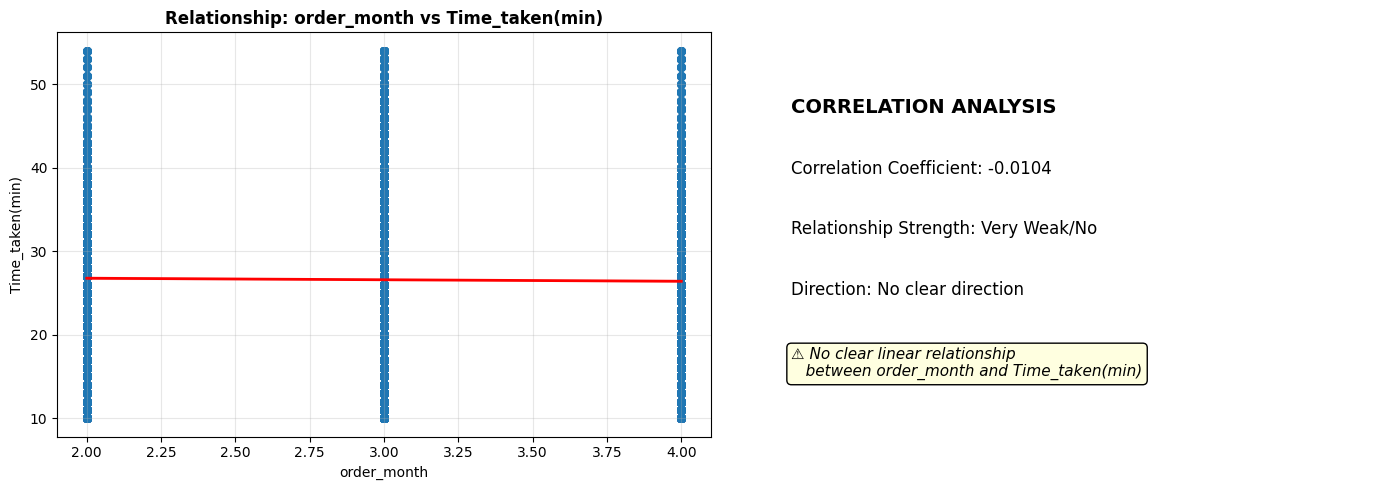


📊 Statistics:
   • order_month - Mean: 3.00, Std: 0.53
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_dayofweek → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


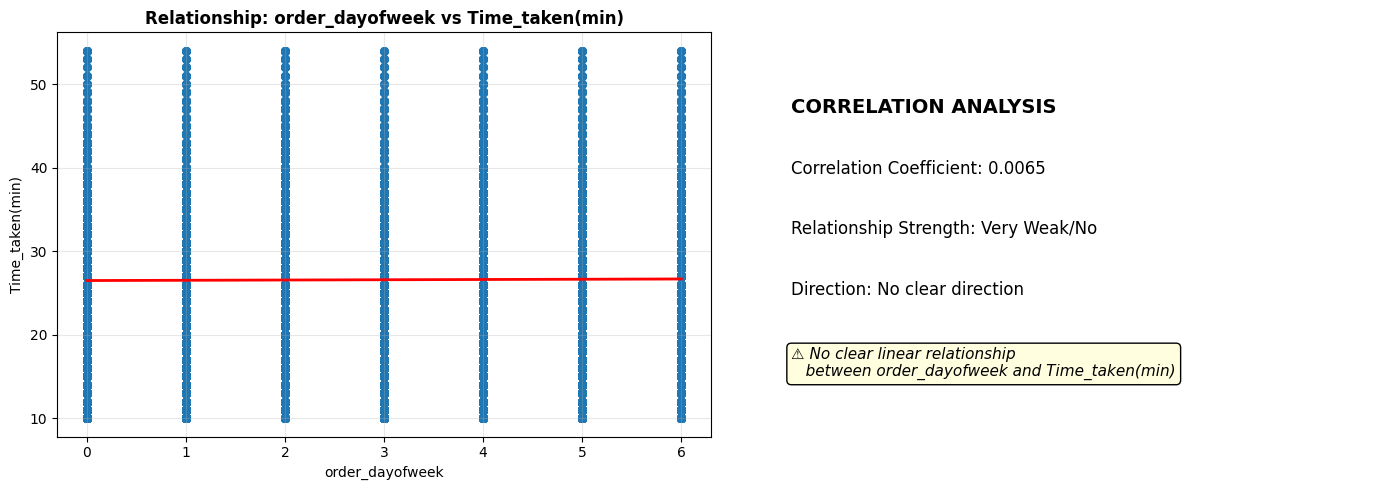


📊 Statistics:
   • order_dayofweek - Mean: 2.99, Std: 1.97
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_hour → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


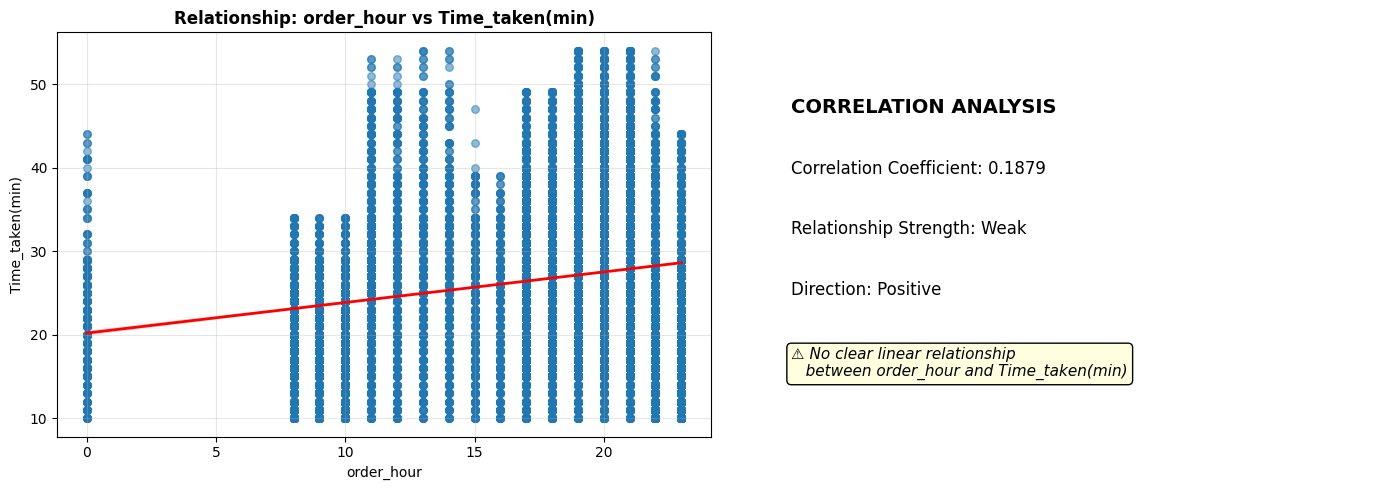


📊 Statistics:
   • order_hour - Mean: 17.44, Std: 4.79
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_minute → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


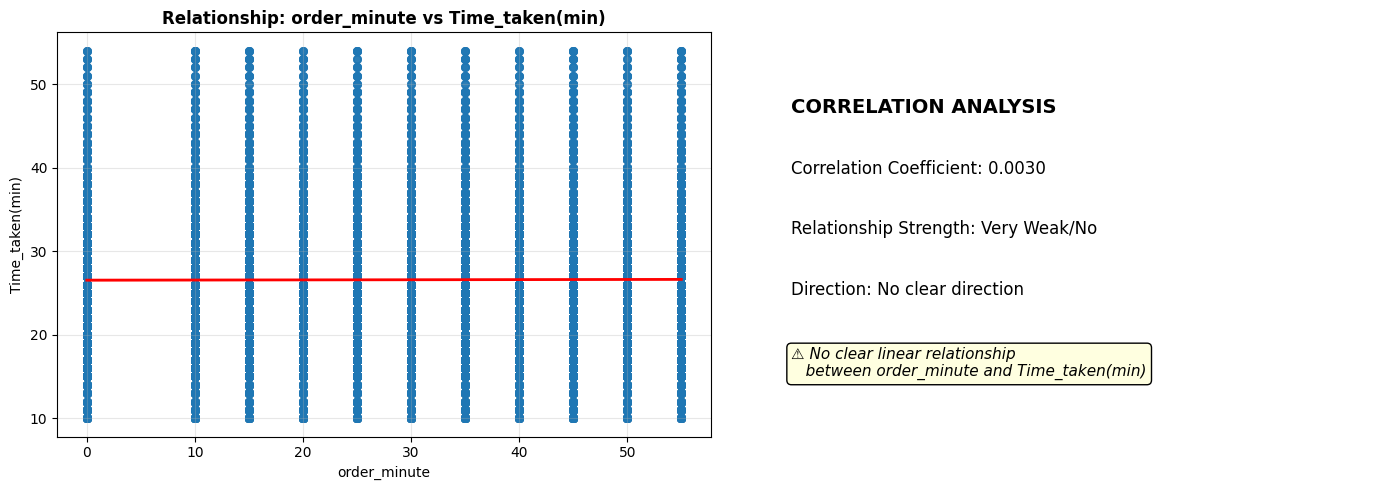


📊 Statistics:
   • order_minute - Mean: 29.60, Std: 16.62
   • Time_taken(min) - Mean: 26.58, Std: 9.33

📊 CATEGORICAL FEATURES vs TARGET

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Time_taken(min) → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


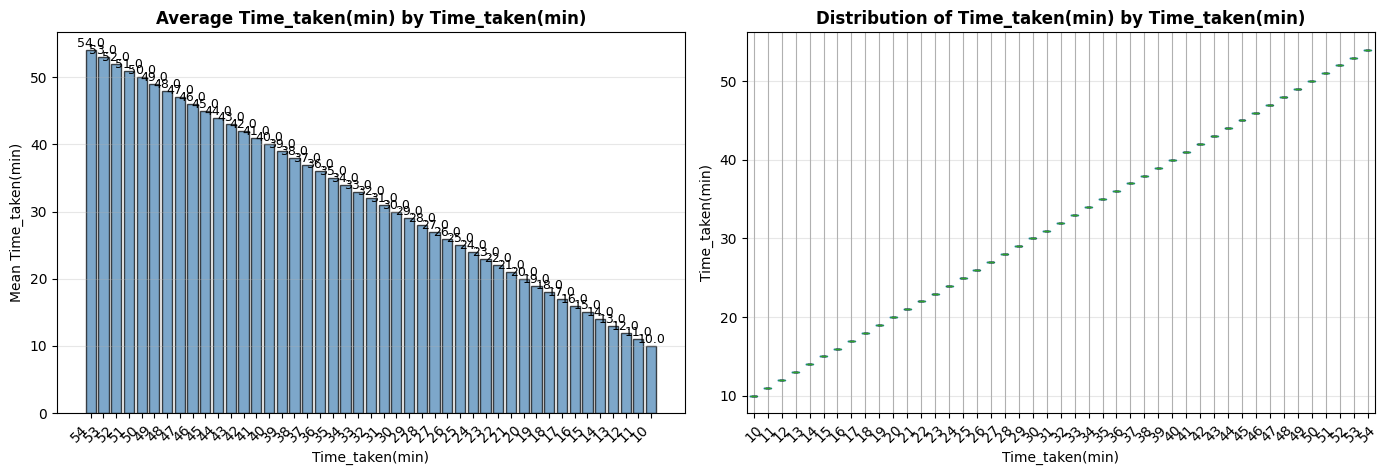


📊 Summary Statistics (sorted by mean Time_taken(min)):
                 mean  median  count  std
Time_taken(min)                          
54               54.0    54.0     78  0.0
53               53.0    53.0     81  0.0
52               52.0    52.0     67  0.0
51               51.0    51.0     81  0.0
50               50.0    50.0     62  0.0
49               49.0    49.0    237  0.0
48               48.0    48.0    233  0.0
47               47.0    47.0    254  0.0
46               46.0    46.0    247  0.0
45               45.0    45.0    209  0.0
44               44.0    44.0    471  0.0
43               43.0    43.0    490  0.0
42               42.0    42.0    488  0.0
41               41.0    41.0    475  0.0
40               40.0    40.0    478  0.0
39               39.0    39.0    741  0.0
38               38.0    38.0    764  0.0
37               37.0    37.0    702  0.0
36               36.0    36.0    724  0.0
35               35.0    35.0    724  0.0
34               34.

d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)



📈 Statistical Significance (ANOVA):
   • F-statistic: inf
   • p-value: 0.0000
   • ✅ Time_taken(min) has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_year → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


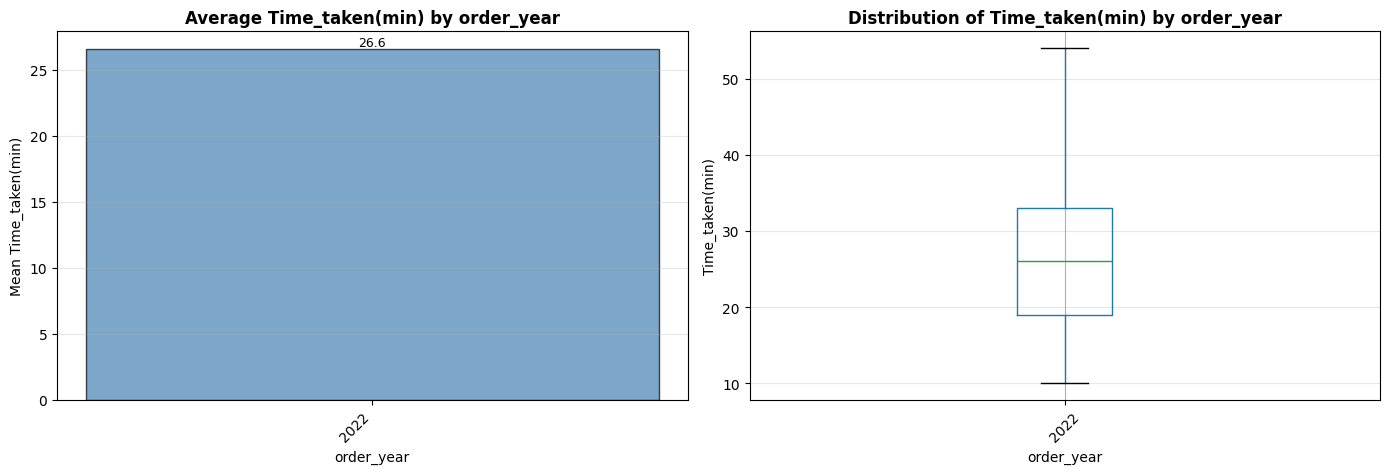


📊 Summary Statistics (sorted by mean Time_taken(min)):
             mean  median  count   std
order_year                            
2022        26.58    26.0  38064  9.33

💡 Key Insight:
   • Best category: '2022' (Avg Time_taken(min): 26.58)
   • Worst category: '2022' (Avg Time_taken(min): 26.58)
   • Difference: 0.00

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_day_name → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


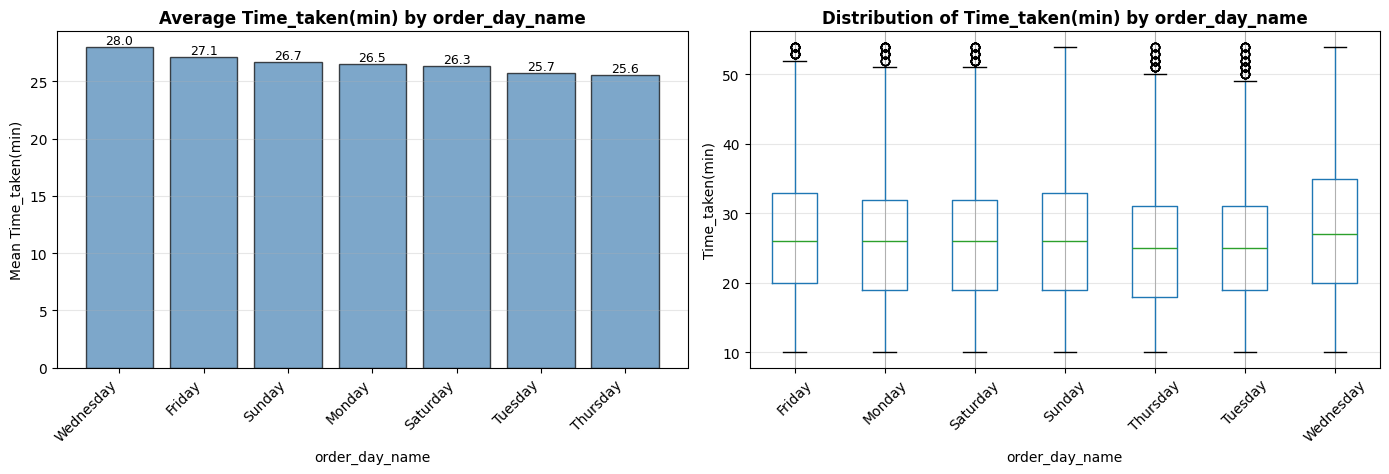


📊 Summary Statistics (sorted by mean Time_taken(min)):
                 mean  median  count   std
order_day_name                            
Wednesday       27.96    27.0   5973  9.62
Friday          27.13    26.0   5834  9.45
Sunday          26.68    26.0   5198  9.35
Monday          26.47    26.0   5181  9.30
Saturday        26.29    26.0   5241  9.29
Tuesday         25.71    25.0   5341  9.06
Thursday        25.57    25.0   5296  8.94

💡 Key Insight:
   • Best category: 'Wednesday' (Avg Time_taken(min): 27.96)
   • Worst category: 'Thursday' (Avg Time_taken(min): 25.57)
   • Difference: 2.39

📈 Statistical Significance (ANOVA):
   • F-statistic: 44.5721
   • p-value: 0.0000
   • ✅ order_day_name has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: is_weekend → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


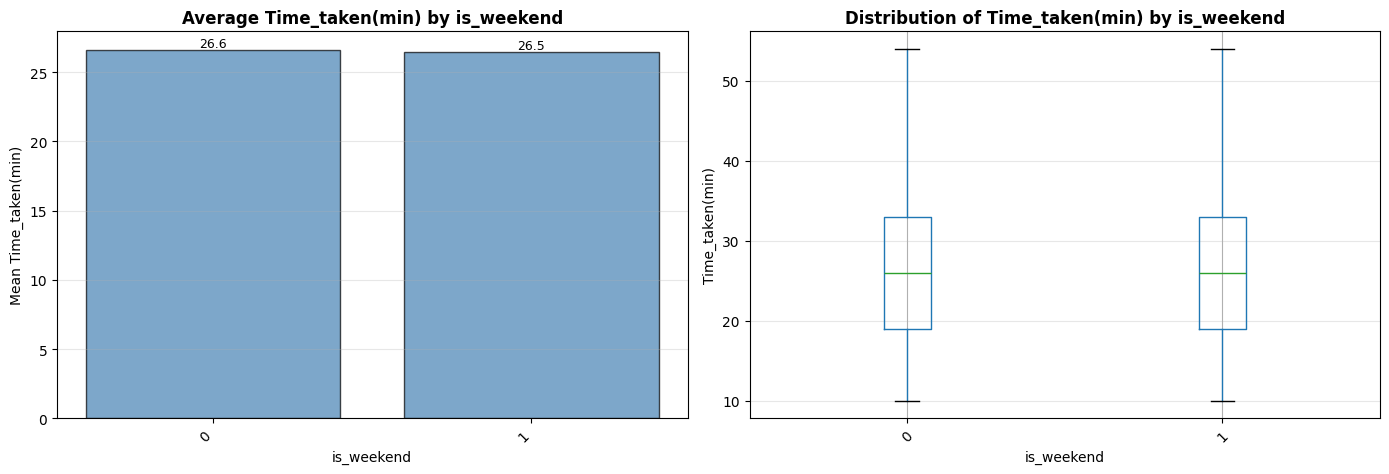


📊 Summary Statistics (sorted by mean Time_taken(min)):
             mean  median  count   std
is_weekend                            
0           26.61    26.0  27625  9.33
1           26.48    26.0  10439  9.32

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 26.61)
   • Worst category: '1' (Avg Time_taken(min): 26.48)
   • Difference: 0.13

📈 Statistical Significance (ANOVA):
   • F-statistic: 1.4206
   • p-value: 0.2333
   • ❌ is_weekend does NOT have significant impact on Time_taken(min)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: time_category → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


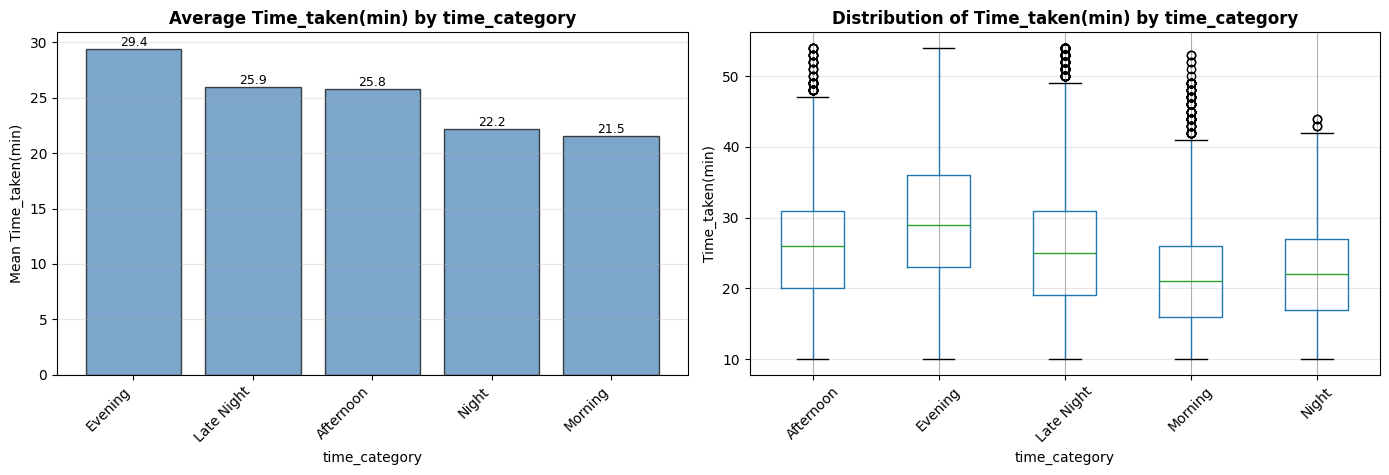


📊 Summary Statistics (sorted by mean Time_taken(min)):
                mean  median  count   std
time_category                            
Evening        29.44    29.0  15723  9.39
Late Night     25.94    25.0  11852  9.36
Afternoon      25.81    26.0   3518  8.11
Night          22.17    22.0    369  7.00
Morning        21.54    21.0   6602  7.04

💡 Key Insight:
   • Best category: 'Evening' (Avg Time_taken(min): 29.44)
   • Worst category: 'Morning' (Avg Time_taken(min): 21.54)
   • Difference: 7.90

📈 Statistical Significance (ANOVA):
   • F-statistic: 983.3453
   • p-value: 0.0000
   • ✅ time_category has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: is_peak_hour → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


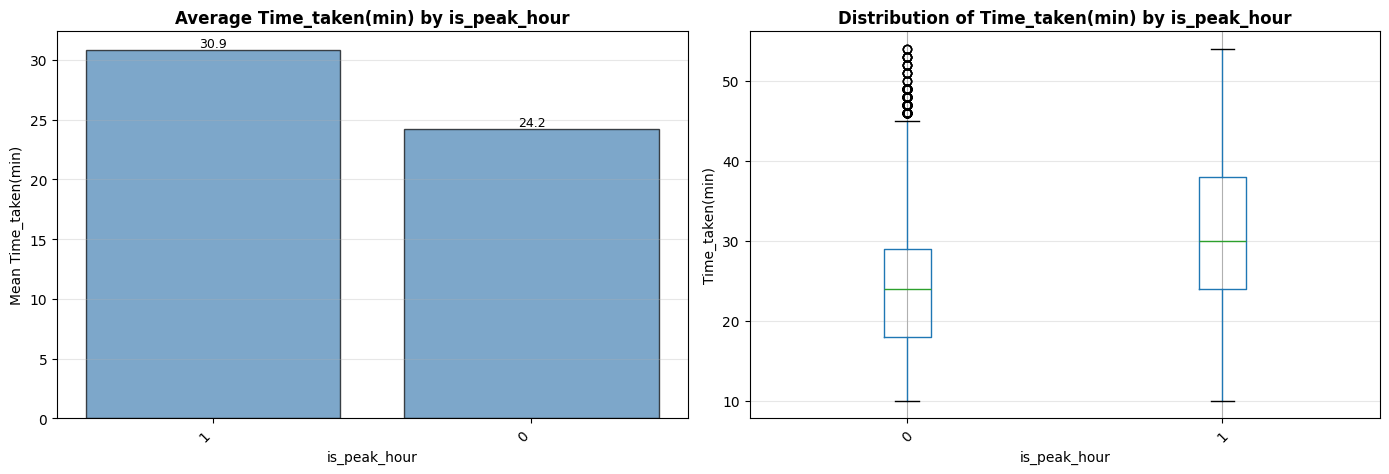


📊 Summary Statistics (sorted by mean Time_taken(min)):
               mean  median  count   std
is_peak_hour                            
1             30.85    30.0  13639  9.79
0             24.19    24.0  24425  8.14

💡 Key Insight:
   • Best category: '1' (Avg Time_taken(min): 30.85)
   • Worst category: '0' (Avg Time_taken(min): 24.19)
   • Difference: 6.66

📈 Statistical Significance (ANOVA):
   • F-statistic: 5062.9770
   • p-value: 0.0000
   • ✅ is_peak_hour has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: is_late_night → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


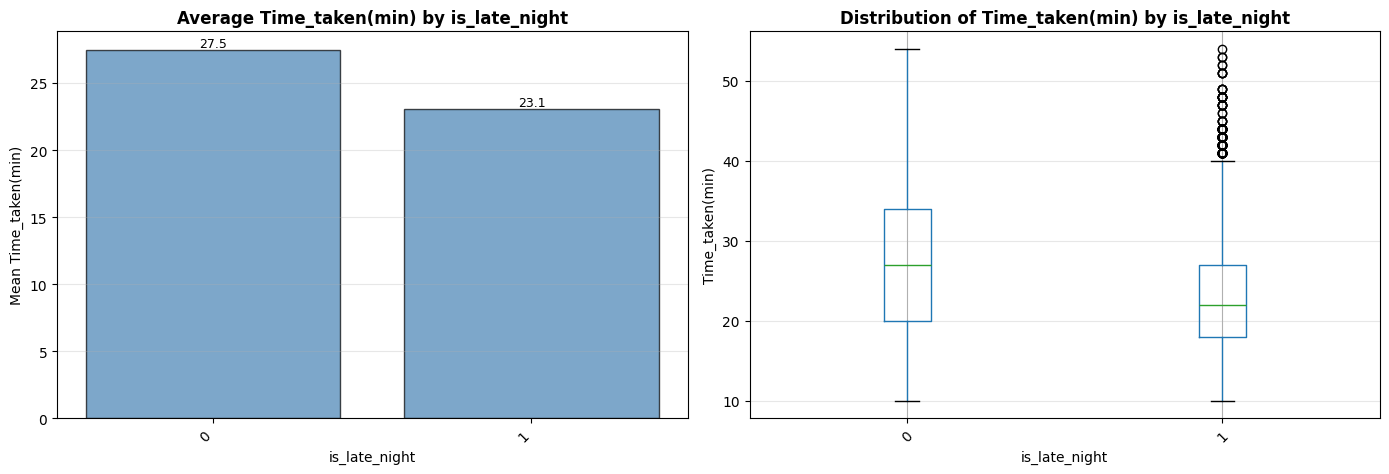


📊 Summary Statistics (sorted by mean Time_taken(min)):
                mean  median  count   std
is_late_night                            
0              27.47    27.0  30324  9.51
1              23.09    22.0   7740  7.64

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 27.47)
   • Worst category: '1' (Avg Time_taken(min): 23.09)
   • Difference: 4.38

📈 Statistical Significance (ANOVA):
   • F-statistic: 1407.8704
   • p-value: 0.0000
   • ✅ is_late_night has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: is_rush_hour → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


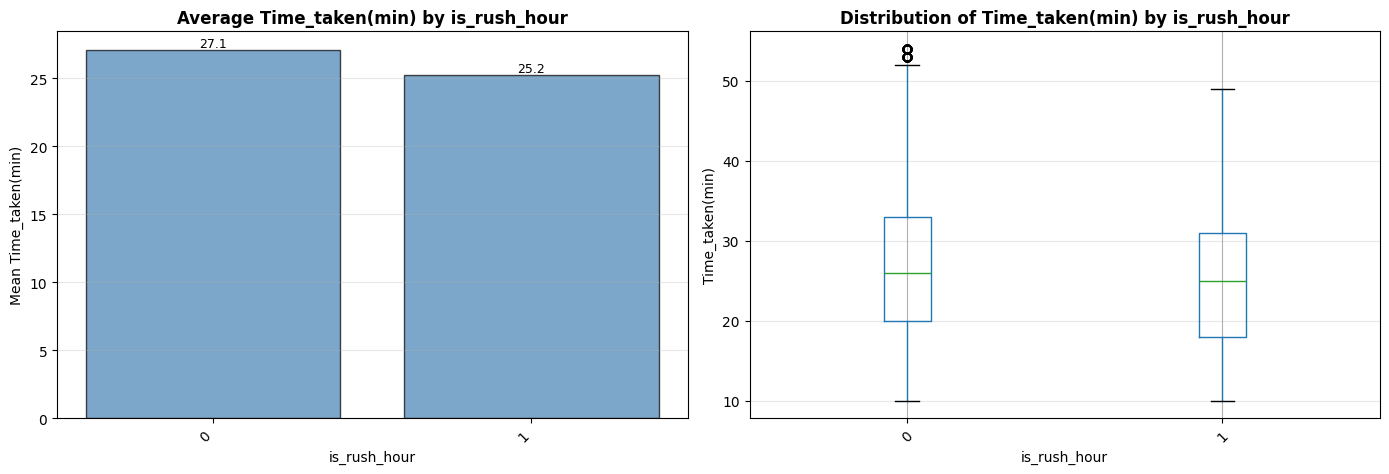


📊 Summary Statistics (sorted by mean Time_taken(min)):
               mean  median  count   std
is_rush_hour                            
0             27.10    26.0  27195  9.57
1             25.25    25.0  10869  8.55

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 27.10)
   • Worst category: '1' (Avg Time_taken(min): 25.25)
   • Difference: 1.85

📈 Statistical Significance (ANOVA):
   • F-statistic: 307.4611
   • p-value: 0.0000
   • ✅ is_rush_hour has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: season → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


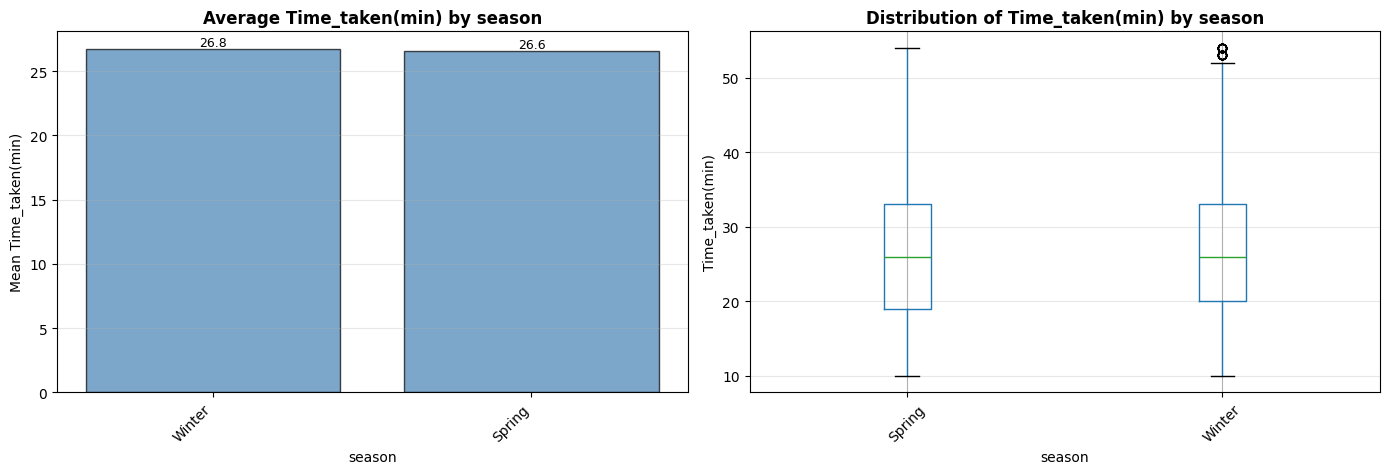


📊 Summary Statistics (sorted by mean Time_taken(min)):
         mean  median  count   std
season                            
Winter  26.75    26.0   5465  9.32
Spring  26.55    26.0  32599  9.33

💡 Key Insight:
   • Best category: 'Winter' (Avg Time_taken(min): 26.75)
   • Worst category: 'Spring' (Avg Time_taken(min): 26.55)
   • Difference: 0.20

📈 Statistical Significance (ANOVA):
   • F-statistic: 2.3453
   • p-value: 0.1257
   • ❌ season does NOT have significant impact on Time_taken(min)


In [58]:
bivariate_analysis(df, num_new, cat_new, tgt)

In [59]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'Time_taken(min)',
       'delivery_city', 'preparation_time_minutes', 'order_day', 'order_month',
       'order_year', 'order_dayofweek', 'order_day_name', 'is_weekend',
       'order_hour', 'order_minute', 'time_category', 'is_peak_hour',
       'is_late_night', 'is_rush_hour', 'season'],
      dtype='object')

In [61]:
df.to_excel("../data/cleaned_eda.xlsx", index=False)